#Entregavel 2

In [ ]:
#Definindo semente

In [ ]:
#instalação das bibliotecas não nativas no Colab
!pip install boruta shap
!pip install xgboost
!pip install lightgbm
!pip install catboost
!pip install tabpfn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
def set_seed(seed=42):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)

    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    except ImportError:
        pass

    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ImportError:
        pass


In [ ]:
#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

#definição de seed para reprodutibilidade
seed = 42

In [ ]:
# Instalando pacotes

In [ ]:
!pip install dfply
!pip install scikit-plot
!pip install graphviz
!pip install dtreeviz
!pip install imbalanced-learn
!pip install pycalib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.4/612.4 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pycalib: filename=pycalib-0.1.0.dev6-py3-none-any.whl size=37283 sha256=c806f088ce47775afc71cb6f1569dddf6dbbe671440df128f8cf4b8af90c00ca
  Stored in directory: /root/.cache/pip/wheels/db/bf/ea/6afc5c6734bb396fd469fd084fbc9c7bc8c34d70092d022389
Successfully built pycalib


In [ ]:
# Carregando pacotes

In [ ]:
import pandas as pd  # processamento de bancos de dados
import numpy as np  # processamento numérico
import matplotlib.pyplot as plt  # geração de gráficos
import seaborn as sns  # geração de gráficos alternativos

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tabpfn import TabPFNClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import roc_curve, precision_recall_curve, auc, classification_report, confusion_matrix
from sklearn.calibration import calibration_curve

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração de gráficos no notebook
%matplotlib inline
plt.rcParams["figure.figsize"] = [10, 5]
plt.style.use("fivethirtyeight")
%config InlineBackend.figure_format = 'retina'

# Configurações de fonte e matemática
from matplotlib import rc
rc('font', **{'family': 'sans-serif', 'sans-serif': ['DejaVu Sans'], 'size': 10})
rc('mathtext', **{'default': 'regular'})

#manipulação de dados
import pandas as pd
import numpy as np

#deepcopy
from copy import deepcopy

#modelos que iremos aplicar nos dados
from xgboost import XGBClassifier

#obtenção do grid e randomized search
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_curve, auc

#visualização de dados
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

#seleção das variáveis
from boruta import BorutaPy

#importancia das variaveis
import shap

# SCIKIT-LEARN

#bibliotecas do sklearn para preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import (roc_curve, auc, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             accuracy_score, brier_score_loss)
from sklearn.model_selection import (KFold, cross_val_score, train_test_split,
                                     GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from sklearn import preprocessing
from tabpfn import TabPFNClassifier

import shap

# Biblioteca dfply
from dfply import *

# Visualização de árvores de decisão
from dtreeviz.trees import *

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix
)

from collections import Counter

# Ignorar warnings
import warnings
warnings.filterwarnings("ignore")

# Definição de semente de aleatoriedade
np.random.seed(42)

#definição de seed para reprodutibilidade
seed = 42

#RJ

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import da base de treino e teste
df_train = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_treino_processados2_ap_2015_2024.csv",
                        encoding='latin1', sep=",")
df_test = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_teste_processados2_ap_2015_2024.csv",
                        encoding='latin1', sep=",")

In [ ]:
#Separação das bases entre X_train, X_test, y_train, y_test
X_train=df_train.drop(columns = "cura")
y_train=df_train.cura
X_test=df_test.drop(columns = "cura")
y_test=df_test.cura

##• Proporção do desfecho (Obrigatório)

In [ ]:
#Visualização da proporção do desfecho na base de treino
y_train.value_counts(normalize=True)

,proportion
cura,
1,0.803888
0,0.196112


In [ ]:
#Visualização da proporção do desfecho na base de teste
y_test.value_counts(normalize=True)

,proportion
cura,
1,0.803703
0,0.196297


#3- Criação e Avaliação dos Modelos Iniciais

---



##Criação e Tuning dos Modelos

###Random Forest

In [ ]:
!pip install hyperopt

In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 14, 1),
    'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
    'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
    'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
}

# Função objetivo
def objective(params):
    model = RandomForestClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_samples_split=params['min_samples_split'],
        min_samples_leaf=params['min_samples_leaf'],
        max_features=params['max_features'],
        random_state=seed,
        n_jobs=-1
    )

    # Acurácia via cross validation (ROC AUC)
    score = cross_val_score(model, X_train, y_train, scoring="roc_auc", cv=5, n_jobs=-1).mean()

    # Hyperopt minimiza → então retornamos o negativo
    return {'loss': -score, 'status': STATUS_OK}

# Armazena resultados
trials = Trials()

# Execução da busca
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,   # Número de iterações (equivale ao n_iter)
    trials=trials,
    rstate=np.random.default_rng(seed)
)

print("\nMelhores hiperparâmetros encontrados:")
print(best)

# Reconstruindo o modelo final com os melhores parâmetros
best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': int(best['max_depth']),
    'min_samples_split': best['min_samples_split'],
    'min_samples_leaf': [5, 10, 26][best['min_samples_leaf']],
    'max_features': [None, 'sqrt', 'log2'][best['max_features']],
    'random_state': seed
}

rf = RandomForestClassifier(**best_params)
rf.fit(X_train, y_train)

print("\nModelo final treinado com Hyperopt.")


100%|██████████| 50/50 [25:02<00:00, 30.05s/trial, best loss: -0.7403457229590478]

Melhores hiperparâmetros encontrados:
{'max_depth': np.float64(14.0), 'max_features': np.int64(2), 'min_samples_leaf': np.int64(0), 'min_samples_split': np.float64(0.01029621509884489), 'n_estimators': np.int64(2)}

Modelo final treinado com Hyperopt.


In [ ]:
# Generate predictions and probabilities
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Impressão
print(f'rf - ROC AUC: {auc_rf:.4f}')

rf - ROC AUC: 0.7435


In [ ]:
# Depois do Hyperopt
auc_rf_hyperopt = roc_auc_score(y_test, y_prob_rf)
params_rf_hyperopt = best_params

In [ ]:
# Modelo e dicionário de busca
rf=RandomForestClassifier(random_state=seed)
rf_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_samples_split': np.arange(0.01, 0.06, 0.01),  # número mínimo de observaçoes ou proporcao para fazer a quebra
    'min_samples_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'max_features': [None, 'sqrt', 'log2']
}

# Criação do random search
rf_rs=RandomizedSearchCV(estimator=rf,
                         param_distributions=rf_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
rf_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do rf ", rf_rs.best_params_)

# Criação do modelo final
rf=rf_rs.best_estimator_


Hiperparametros do rf  {'n_estimators': np.int64(300), 'min_samples_split': np.float64(0.01), 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': np.int64(10)}


In [ ]:
# Generate predictions and probabilities
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Métricas
auc_rf = roc_auc_score(y_test, y_prob_rf)

# Impressão
print(f'rf - ROC AUC: {auc_rf:.4f}')

rf - ROC AUC: 0.7441


In [ ]:
# Depois do Random Search
auc_rf_rs = roc_auc_score(y_test, y_prob_rf)
params_rf_rs = rf_rs.best_params_

In [ ]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.2 MB/s eta 0:00:00


In [ ]:
import optuna
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score


In [ ]:
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc
# ===============================
# IMPORTS
# ===============================
import numpy as np
import optuna

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ===============================
# OPTUNA - FUNÇÃO OBJETIVO
# ===============================
def objective(trial):

    rf = RandomForestClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
        min_samples_leaf=trial.suggest_int("min_samples_leaf", 5, 26),
        max_features=trial.suggest_categorical(
            "max_features", [None, "sqrt", "log2"]
        ),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        rf,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# TREINO DO MODELO FINAL
# ===============================
rf = RandomForestClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

rf.fit(X_train, y_train)


# ===============================
# PREDIÇÕES
# ===============================
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]




[I 2026-05-07 14:26:11,520] A new study created in memory with name: no-name-8aab19ff-8ed0-4278-ab3f-8bb53f9b516c
[I 2026-05-07 14:26:44,648] Trial 0 finished with value: 0.7365689418236896 and parameters: {'n_estimators': 500, 'max_depth': 7, 'min_samples_split': 0.025381681860378077, 'min_samples_leaf': 9, 'max_features': 'log2'}. Best is trial 0 with value: 0.7365689418236896.
[I 2026-05-07 14:27:06,535] Trial 1 finished with value: 0.7408390667355869 and parameters: {'n_estimators': 300, 'max_depth': 10, 'min_samples_split': 0.014220103434700381, 'min_samples_leaf': 21, 'max_features': 'log2'}. Best is trial 1 with value: 0.7408390667355869.
[I 2026-05-07 14:27:35,096] Trial 2 finished with value: 0.739439161608679 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_samples_split': 0.011730567177507081, 'min_samples_leaf': 12, 'max_features': 'log2'}. Best is trial 1 with value: 0.7408390667355869.
[I 2026-05-07 14:27:47,057] Trial 3 finished with value: 0.7358611748085188 a


Melhor AUC (CV): 0.7431230353501652
Melhores hiperparâmetros:
{'n_estimators': 500, 'max_depth': 15, 'min_samples_split': 0.011369833481632412, 'min_samples_leaf': 20, 'max_features': 'sqrt'}


In [ ]:
# ===============================
# MÉTRICAS COM THRESHOLD FIXO
# ===============================
threshold = 0.5

# Converter probabilidade -> classe
y_pred_rf_thr = (y_prob_rf >= threshold).astype(int)

# Métricas
auc_rf = roc_auc_score(y_test, y_prob_rf)  # AUC NÃO muda com threshold

# ===============================
# PRINT
# ===============================
print(f"ROC AUC: {auc_rf:.4f}")


ROC AUC: 0.7442


In [ ]:
# Depois do Optuna
auc_rf_optuna = roc_auc_score(y_test, y_prob_rf)
params_rf_optuna = study.best_params

In [ ]:
import pandas as pd

# ===============================
# AUCs já salvos
# ===============================
# auc_rf_rs, auc_rf_hyperopt, auc_rf_optuna

# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
params_rf_rs = rf_rs.best_params_

# Hyperopt
params_rf_hyperopt = best_params

# Optuna
params_rf_optuna = study.best_params

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [auc_rf_rs],
    'Hyperopt': [auc_rf_hyperopt],
    'Optuna': [auc_rf_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_rf = pd.DataFrame({
    'Modelo': ['RandomForest'],
    'RandomSearch': [params_rf_rs],
    'Hyperopt': [params_rf_hyperopt],
    'Optuna': [params_rf_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_rf)


===== Tabela AUC-ROC =====
         Modelo  RandomSearch  Hyperopt    Optuna
0  RandomForest      0.744082  0.743493  0.744177


In [ ]:
# Expandindo cada dicionário em colunas
df_rs = pd.DataFrame([params_rf_rs])
df_hyperopt = pd.DataFrame([params_rf_hyperopt])
df_optuna = pd.DataFrame([params_rf_optuna])

# Adicionando prefixo para identificar a origem
df_rs = df_rs.add_prefix("RS_")
df_hyperopt = df_hyperopt.add_prefix("Hyperopt_")
df_optuna = df_optuna.add_prefix("Optuna_")

# Concatenar em uma tabela única
df_params_rf_expanded = pd.concat([df_rs, df_hyperopt, df_optuna], axis=1)
df_params_rf_expanded.insert(0, 'Modelo', 'RandomForest')

# Mostrar tabela final
print("===== Tabela Hiperparâmetros Expandidos =====")
print(df_params_rf_expanded)

===== Tabela Hiperparâmetros Expandidos =====
         Modelo  RS_n_estimators  RS_min_samples_split  RS_min_samples_leaf  \
0  RandomForest              300                  0.01                   10   

  RS_max_features  RS_max_depth  Hyperopt_n_estimators  Hyperopt_max_depth  \
0            log2            10                    400                  14   

   Hyperopt_min_samples_split  Hyperopt_min_samples_leaf  \
0                    0.010296                          5   

  Hyperopt_max_features  Hyperopt_random_state  Optuna_n_estimators  \
0                  log2                     42                  500   

   Optuna_max_depth  Optuna_min_samples_split  Optuna_min_samples_leaf  \
0                15                   0.01137                       20   

  Optuna_max_features  
0                sqrt  


In [ ]:
# Supondo que você já tenha:
# df_auc_rf =
#          Modelo  RandomSearch  Hyperopt   Optuna
# 0  RandomForest      0.687625  0.702539  0.69042

# 1️⃣ Encontrar a coluna com o maior valor (exceto a coluna 'Modelo')
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_auc = df_auc_rf.drop(columns='Modelo').max(axis=1)[0]
best_model = df_auc_rf['Modelo'][0]

print(f"✅ Modelo com maior AUC-ROC: {best_model} ({best_method_rf}) = {best_auc:.4f}")

✅ Modelo com maior AUC-ROC: RandomForest (Optuna) = 0.7442


In [ ]:
# ===============================
# Tabelas de hiperparâmetros expandidas
# Supondo que você tenha algo como df_params_expanded
# ===============================
# df_params_expanded =
#          Modelo  RS_n_estimators  RS_min_samples_split ... Optuna_max_features

# Determinar o melhor método
best_method_rf = df_auc_rf.drop(columns='Modelo').idxmax(axis=1)[0]
best_model_name = df_auc_rf['Modelo'][0]
print(f"✅ Melhor AUC-ROC detectada: {best_model_name} ({best_method_rf})")

# Mapear para os nomes de colunas no DataFrame de hiperparâmetros
method_prefix_map = {
    'RandomSearch': 'RS_',
    'Hyperopt': 'Hyperopt_',
    'Optuna': 'Optuna_'
}

prefix = method_prefix_map[best_method_rf]

# Extrair os hiperparâmetros correspondentes
best_params = {col.replace(prefix, ''): df_params_rf_expanded[col][0]
               for col in df_params_rf_expanded.columns if col.startswith(prefix)}

# Ajustar tipos de dados conforme necessário (int, float)
for key in ['n_estimators', 'max_depth', 'min_samples_leaf']:
    if key in best_params:
        best_params[key] = int(best_params[key])

# ===============================
# Treinar o modelo final com os melhores hiperparâmetros
# ===============================
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    **best_params,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# ===============================
# Predições e AUC
# ===============================
y_prob = rf.predict_proba(X_test)[:, 1]
from sklearn.metrics import roc_auc_score
auc_rf = roc_auc_score(y_test, y_prob)

print(f"✅ ROC AUC do melhor modelo ({best_method_rf}): {auc_rf:.4f}")

✅ Melhor AUC-ROC detectada: RandomForest (Optuna)
✅ ROC AUC do melhor modelo (Optuna): 0.7442


In [ ]:
# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_rf}):")

best_params_rf_completo = best_params

for param, value in best_params_rf_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo RandomForest (Optuna):
n_estimators: 500
max_depth: 15
min_samples_split: 0.011369833481632412
min_samples_leaf: 20
max_features: sqrt


###LGBM

In [ ]:
# ===============================
# IMPORTS
# ===============================
!pip install hyperopt

from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
import numpy as np

# ===============================
# Espaço de busca do Hyperopt
# ===============================
space_lgb = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# ===============================
# Função objetivo Hyperopt
# ===============================
def objective_hyperopt(params):
    lgb = LGBMClassifier(
        n_estimators=int(params['n_estimators']),
        max_depth=int(params['max_depth']),
        min_data_in_leaf=int(params['min_data_in_leaf']),
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        n_jobs=-1
    )

    # Cross-validation ROC-AUC
    score = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring='roc_auc',
        cv=5,
        n_jobs=-1
    ).mean()

    # Hyperopt minimiza, então retornamos negativo
    return {'loss': -score, 'status': STATUS_OK}

# ===============================
# Executar Hyperopt
# ===============================
trials = Trials()

best_hyperopt = fmin(
    fn=objective_hyperopt,
    space=space_lgb,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed)
)

# ===============================
# Reconstruir dicionário final de hiperparâmetros
# ===============================
best_params_hyperopt = {
    'n_estimators': [200, 300, 400, 500][best_hyperopt['n_estimators']],
    'max_depth': int(best_hyperopt['max_depth']),
    'min_data_in_leaf': int(best_hyperopt['min_data_in_leaf']),
    'learning_rate': best_hyperopt['learning_rate'],
    'subsample': best_hyperopt['subsample'],
    'colsample_bytree': best_hyperopt['colsample_bytree'],
    'reg_alpha': best_hyperopt['reg_alpha'],
    'reg_lambda': best_hyperopt['reg_lambda']
}

print("\n✅ Melhores hiperparâmetros Hyperopt:")
print(best_params_hyperopt)

# ===============================
# Treinar modelo final LGBM
# ===============================
lgb_model = LGBMClassifier(
    **best_params_hyperopt,
    random_state=seed,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

# ===============================
# Predições e ROC-AUC
# ===============================
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]
auc_lgb_hyperopt = roc_auc_score(y_test, y_prob_lgb)
print(f"✅ ROC-AUC teste Hyperopt: {auc_lgb_hyperopt:.4f}")

100%|██████████| 50/50 [14:44<00:00, 17.68s/trial, best loss: -0.7454132088616415]

✅ Melhores hiperparâmetros Hyperopt:
{'n_estimators': 400, 'max_depth': 9, 'min_data_in_leaf': 11, 'learning_rate': np.float64(0.011962282617989439), 'subsample': np.float64(0.7614117202960703), 'colsample_bytree': np.float64(0.6000569217307167), 'reg_alpha': np.float64(0.09253034946783316), 'reg_lambda': np.float64(1.9414064002606777)}
[LightGBM] [Warning] min_data_in_leaf is set=11, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=11
[LightGBM] [Warning] min_data_in_leaf is set=11, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=11
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007603 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 173
[Lig

In [ ]:
# ===============================
# IMPORTS
# ===============================
import optuna
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

# ===============================
# FUNÇÃO OBJETIVO
# ===============================
def objective_lgb(trial):

    lgb = LGBMClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 5, 15),
        min_data_in_leaf=trial.suggest_int("min_data_in_leaf", 5, 26),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        n_jobs=-1
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    auc = cross_val_score(
        lgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


# ===============================
# RODAR OPTUNA
# ===============================
study = optuna.create_study(direction="maximize")
study.optimize(objective_lgb, n_trials=50)

print("\nMelhor AUC (CV):", study.best_value)
print("Melhores hiperparâmetros:")
print(study.best_params)


# ===============================
# MODELO FINAL (lgb)
# ===============================
lgb = LGBMClassifier(
    **study.best_params,
    random_state=seed,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

# ===============================
# PREDIÇÕES
# ===============================
y_pred_lgb = lgb.predict(X_test)
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

print("ROC-AUC teste:", roc_auc_score(y_test, y_prob_lgb))


[I 2026-05-07 15:05:58,222] A new study created in memory with name: no-name-a4f7fdeb-94df-45f0-9af5-584c863c6993
[I 2026-05-07 15:06:34,895] Trial 0 finished with value: 0.7399820782949652 and parameters: {'n_estimators': 400, 'max_depth': 6, 'min_data_in_leaf': 7, 'learning_rate': 0.06581469415014028, 'subsample': 0.8922612135344095, 'colsample_bytree': 0.9286252319239212, 'reg_alpha': 0.08362065096479479, 'reg_lambda': 1.1960733944662865}. Best is trial 0 with value: 0.7399820782949652.
[I 2026-05-07 15:07:20,780] Trial 1 finished with value: 0.7476172465204017 and parameters: {'n_estimators': 400, 'max_depth': 14, 'min_data_in_leaf': 23, 'learning_rate': 0.011255590145064755, 'subsample': 0.9279430285634, 'colsample_bytree': 0.6929262819505779, 'reg_alpha': 0.0011348096765616618, 'reg_lambda': 1.545457882811109}. Best is trial 1 with value: 0.7476172465204017.
[I 2026-05-07 15:07:29,714] Trial 2 finished with value: 0.7469233702243961 and parameters: {'n_estimators': 200, 'max_dept


Melhor AUC (CV): 0.7486339596483581
Melhores hiperparâmetros:
{'n_estimators': 300, 'max_depth': 13, 'min_data_in_leaf': 19, 'learning_rate': 0.02417865395221982, 'subsample': 0.7204030268351862, 'colsample_bytree': 0.6108955180116565, 'reg_alpha': 0.9776414413482496, 'reg_lambda': 1.92035248364019}
[LightGBM] [Warning] min_data_in_leaf is set=19, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=19
[LightGBM] [Warning] min_data_in_leaf is set=19, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=19
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015115 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 23971, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803888 -> initscore=1.410774
[LightGBM] [Info]

In [ ]:
for param, value in study.best_params.items():
    print(f"{param}: {value}")


n_estimators: 300
max_depth: 13
min_data_in_leaf: 19
learning_rate: 0.02417865395221982
subsample: 0.7204030268351862
colsample_bytree: 0.6108955180116565
reg_alpha: 0.9776414413482496
reg_lambda: 1.92035248364019


#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=19, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=19
lgb - ROC AUC: 0.7505


In [ ]:
# Depois do Optuna
auc_lgb_optuna = roc_auc_score(y_test, y_prob_lgb)
params_lgb_optuna = study.best_params

In [ ]:
# Modelo e dicionário de busca
lgb=LGBMClassifier(random_state=seed)
lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
}

# Criação do random search
lgb_rs=RandomizedSearchCV(estimator=lgb,
                         param_distributions=lgb_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
lgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do lgb ", lgb_rs.best_params_)

# Criação do modelo final
lgb=lgb_rs.best_estimator_

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008048 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 23971, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803888 -> initscore=1.410774
[LightGBM] [Info] Start training from score 1.410774
Hiperparametros do lgb  {'subsample': np.float64(0.6), 'reg_lambda': np.float64(1.5), 'reg_alpha': np.float64(0.1), 'n_estimators': np.int64(500), 'min_data_in_leaf': 26, 'max_depth': np.int64(10), 'lea

#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_lgb = (y_prob_lgb >= threshold).astype(int)

# Métricas
auc_lgb = roc_auc_score(y_test, y_prob_lgb)  # Continua usando probabilidade para o AUC

# Impressão
print(f'lgb - ROC AUC: {auc_lgb:.4f}')

[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
lgb - ROC AUC: 0.7496


In [ ]:
# Depois
auc_lgb_rs = roc_auc_score(y_test, y_prob_lgb)
params_lgb_rs = lgb_rs.best_params_

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# ===============================
# AUCs já salvos
# ===============================
# auc_lgb_rs, auc_lgb_hyperopt, auc_lgb_optuna

# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
params_lgb_rs = lgb_rs.best_params_

# Hyperopt
params_lgb_hyperopt = best_params_hyperopt  # troque pelo seu dicionário Hyperopt

# Optuna
params_lgb_optuna = study.best_params  # se usar Optuna

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_lgb = pd.DataFrame({
    'Modelo': ['LightGBM'],
    'RandomSearch': [auc_lgb_rs],
    'Hyperopt': [auc_lgb_hyperopt],
    'Optuna': [auc_lgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_lgb = pd.DataFrame({
    'Modelo': ['LightGBM'],
    'RandomSearch': [params_lgb_rs],
    'Hyperopt': [params_lgb_hyperopt],
    'Optuna': [params_lgb_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_lgb)

# Expandindo cada dicionário em colunas
df_rs = pd.DataFrame([params_lgb_rs]).add_prefix("RS_")
df_hyperopt = pd.DataFrame([params_lgb_hyperopt]).add_prefix("Hyperopt_")
df_optuna = pd.DataFrame([params_lgb_optuna]).add_prefix("Optuna_")

# Concatenar em uma tabela única
df_params_lgb_expanded = pd.concat([df_rs, df_hyperopt, df_optuna], axis=1)
df_params_lgb_expanded.insert(0, 'Modelo', 'LightGBM')

print("===== Tabela Hiperparâmetros Expandidos =====")
print(df_params_lgb_expanded)

# ===============================
# Detectar o melhor método
# ===============================
best_method_lgb = df_auc_lgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_model_name = df_auc_lgb['Modelo'][0]
print(f"✅ Melhor AUC-ROC detectada: {best_model_name} ({best_method_lgb})")

# Mapear prefixo das colunas
method_prefix_map = {
    'RandomSearch': 'RS_',
    'Hyperopt': 'Hyperopt_',
    'Optuna': 'Optuna_'
}
prefix = method_prefix_map[best_method_lgb]

# Extrair os hiperparâmetros correspondentes
best_params = {col.replace(prefix, ''): df_params_lgb_expanded[col][0]
               for col in df_params_lgb_expanded.columns if col.startswith(prefix)}

# Ajustar tipos de dados conforme necessário (int, float)
for key in ['n_estimators', 'max_depth', 'num_leaves']:
    if key in best_params:
        best_params[key] = int(best_params[key])

# ===============================
# Treinar o modelo final LGBM com os melhores hiperparâmetros
# ===============================
lgb_model = LGBMClassifier(
    **best_params,
    n_jobs=-1,
    random_state=42
)

lgb_model.fit(X_train, y_train)

# ===============================
# Predições e AUC
# ===============================
y_prob = lgb_model.predict_proba(X_test)[:, 1]
auc_lgb_best = roc_auc_score(y_test, y_prob)
print(f"✅ ROC AUC do melhor modelo ({best_method_lgb}): {auc_lgb_best:.4f}")

# ===============================
# Mostrar os melhores hiperparâmetros
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_lgb}):")
for param, value in best_params.items():
    print(f"{param}: {value}")

===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  LightGBM      0.749557  0.749844  0.750474
===== Tabela Hiperparâmetros Expandidos =====
     Modelo  RS_subsample  RS_reg_lambda  RS_reg_alpha  RS_n_estimators  \
0  LightGBM           0.6            1.5           0.1              500   

   RS_min_data_in_leaf  RS_max_depth  RS_learning_rate  RS_colsample_bytree  \
0                   26            10              0.01                  0.6   

   Hyperopt_n_estimators  ...  Hyperopt_reg_alpha  Hyperopt_reg_lambda  \
0                    400  ...             0.09253             1.941406   

   Optuna_n_estimators  Optuna_max_depth  Optuna_min_data_in_leaf  \
0                  300                13                       19   

   Optuna_learning_rate  Optuna_subsample  Optuna_colsample_bytree  \
0              0.024179          0.720403                 0.610896   

   Optuna_reg_alpha  Optuna_reg_lambda  
0          0.977641           1.920352  

[1 rows x 25 

In [ ]:
# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_lgb}):")

best_params_lgb_completo = best_params

for param, value in best_params_lgb_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo LightGBM (Optuna):
n_estimators: 300
max_depth: 13
min_data_in_leaf: 19
learning_rate: 0.02417865395221982
subsample: 0.7204030268351862
colsample_bytree: 0.6108955180116565
reg_alpha: 0.9776414413482496
reg_lambda: 1.92035248364019


###CatBoost

In [ ]:
# Modelo e dicionário de busca
cat = CatBoostClassifier(random_state=seed)
cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2

}

# Criação do random search
cat_rs=RandomizedSearchCV(estimator=cat,
                         param_distributions=cat_dict,
                         scoring="roc_auc",
                         cv=5,
                         n_iter=20,
                         n_jobs=-1,
                         random_state=seed
                         )

# Fit do random search
cat_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do cat ", cat_rs.best_params_)

# Criação do modelo final
cat=cat_rs.best_estimator_

0:	learn: 0.6768757	total: 59.5ms	remaining: 23.7s
1:	learn: 0.6614637	total: 67.4ms	remaining: 13.4s
2:	learn: 0.6468139	total: 74.5ms	remaining: 9.86s
3:	learn: 0.6346102	total: 81.4ms	remaining: 8.05s
4:	learn: 0.6214926	total: 88.1ms	remaining: 6.96s
5:	learn: 0.6099747	total: 94.7ms	remaining: 6.22s
6:	learn: 0.5992662	total: 102ms	remaining: 5.7s
7:	learn: 0.5900245	total: 108ms	remaining: 5.3s
8:	learn: 0.5813922	total: 115ms	remaining: 4.99s
9:	learn: 0.5730833	total: 121ms	remaining: 4.73s
10:	learn: 0.5644156	total: 128ms	remaining: 4.54s
11:	learn: 0.5562410	total: 136ms	remaining: 4.38s
12:	learn: 0.5497165	total: 147ms	remaining: 4.37s
13:	learn: 0.5428859	total: 154ms	remaining: 4.24s
14:	learn: 0.5372459	total: 161ms	remaining: 4.14s
15:	learn: 0.5317032	total: 167ms	remaining: 4s
16:	learn: 0.5260784	total: 174ms	remaining: 3.92s
17:	learn: 0.5209868	total: 181ms	remaining: 3.83s
18:	learn: 0.5157135	total: 188ms	remaining: 3.76s
19:	learn: 0.5110515	total: 195ms	remain

#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_cat = cat.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_cat = (y_prob_cat >= threshold).astype(int)

# Métricas
auc_cat = roc_auc_score(y_test, y_prob_cat)  # Continua usando probabilidade para o AUC

# Impressão
print(f'cat - ROC AUC: {auc_cat:.4f}')


cat - ROC AUC: 0.7504


In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat)
params_cat_rs = cat_rs.best_params_

In [ ]:
!pip install hyperopt catboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca do Hyperopt equivalente ao cat_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = CatBoostClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        min_data_in_leaf=params['min_data_in_leaf'],
        subsample=params['subsample'],
        reg_lambda=params['reg_lambda'],
        random_state=seed,
        verbose=0
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Armazena histórico da otimização
trials = Trials()

# Execução da busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,   # TPE = otimização bayesiana
    max_evals=50,       # equivalente ao n_iter do RandomSearchCV
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos parâmetros (hp.choice retorna índice)
cat_hyperopt_tuned_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'min_data_in_leaf': [5, 10, 26][best['min_data_in_leaf']],
    'subsample': best['subsample'],
    'reg_lambda': best['reg_lambda'],
    'random_state': seed
}

print("\nMelhores hiperparâmetros encontrados:")
print(cat_hyperopt_tuned_params)

# Modelo final
cat = CatBoostClassifier(**cat_hyperopt_tuned_params, verbose=0)
cat.fit(X_train, y_train)

print("\nModelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.")

100%|██████████| 50/50 [32:31<00:00, 39.04s/trial, best loss: -0.7481392971046235]

Melhores hiperparâmetros encontrados:
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': np.float64(0.8615974512244434), 'reg_lambda': np.float64(1.5492868223517804), 'random_state': 42}

Modelo CatBoost treinado com os melhores hiperparâmetros da Hyperopt.


In [ ]:
# Generate predictions and probabilities
y_pred_cat = cat.predict(X_test)
y_prob_cat = cat.predict_proba(X_test)[:, 1]

# Métricas
auc_cat = roc_auc_score(y_test, y_prob_cat)

# Impressão
print(f'CatBoost - ROC AUC: {auc_cat:.4f}')

CatBoost - ROC AUC: 0.7506


In [ ]:
auc_cat_hyperopt = roc_auc_score(y_test, y_prob_cat)
params_cat_hyperopt = cat_hyperopt_tuned_params

In [ ]:
import optuna
import numpy as np

from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_cat(trial):

    cat = CatBoostClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        random_state=seed,
        verbose=0
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        cat,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
study_cat = optuna.create_study(direction="maximize")
study_cat.optimize(objective_cat, n_trials=50)


[I 2026-05-07 16:11:08,874] A new study created in memory with name: no-name-537333fd-67cb-4247-b595-83df3803f8a1
[I 2026-05-07 16:11:37,180] Trial 0 finished with value: 0.7482929222040056 and parameters: {'n_estimators': 300, 'max_depth': 5, 'min_data_in_leaf': 10, 'subsample': 0.9612598454708534, 'reg_lambda': 1.3055566374294099}. Best is trial 0 with value: 0.7482929222040056.
[I 2026-05-07 16:12:00,462] Trial 1 finished with value: 0.7478178049417621 and parameters: {'n_estimators': 200, 'max_depth': 6, 'min_data_in_leaf': 26, 'subsample': 0.960328735422874, 'reg_lambda': 1.6544045324679042}. Best is trial 0 with value: 0.7482929222040056.
[I 2026-05-07 16:12:33,961] Trial 2 finished with value: 0.7487451719662216 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_data_in_leaf': 26, 'subsample': 0.7724733405423541, 'reg_lambda': 1.8836400400274642}. Best is trial 2 with value: 0.7487451719662216.
[I 2026-05-07 16:12:46,147] Trial 3 finished with value: 0.7475956587147247 a

In [ ]:
print("Melhor AUC (CV):", study_cat.best_value)
print("Melhores hiperparâmetros (CatBoost):")
print(study_cat.best_params)


Melhor AUC (CV): 0.7501673614632083
Melhores hiperparâmetros (CatBoost):
{'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.8636357417648474, 'reg_lambda': 1.402679718749928}


In [ ]:
cat_final = CatBoostClassifier(
    **study_cat.best_params,
    random_state=seed,
    verbose=0
)

cat_final.fit(X_train, y_train)


CatBoostClassifier(max_depth=5, min_data_in_leaf=26, n_estimators=400, random_state=42, reg_lambda=1.402679718749928, subsample=0.8636357417648474, verbose=0)

Predicoes

In [ ]:
y_pred_cat = cat_final.predict(X_test)
y_prob_cat = cat_final.predict_proba(X_test)[:, 1]


In [ ]:
auc_cat = roc_auc_score(y_test, y_prob_cat)



In [ ]:
print(f"ROC AUC: {auc_cat:.4f}")


ROC AUC: 0.7519


In [ ]:
# Depois
auc_cat_optuna = roc_auc_score(y_test, y_prob_cat)
params_cat_optuna = study_cat.best_params

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ===============================
# AUCs já salvos
# ===============================
# auc_cat_rs, auc_cat_hyperopt, auc_cat_optuna

# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
params_cat_rs = cat_rs.best_params_

# Hyperopt
# Correctly assign best_params from CatBoost Hyperopt (from cell Ir1gVsXckvCq)
params_cat_hyperopt = cat_hyperopt_tuned_params

# Optuna
# Correctly assign best_params from CatBoost Optuna (from cell _KkYyQC_iso0)
params_cat_optuna = study_cat.best_params

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_cat = pd.DataFrame({
    'Modelo': ['CatBoost'],
    'RandomSearch': [auc_cat_rs],
    'Hyperopt': [auc_cat_hyperopt],
    'Optuna': [auc_cat_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_cat = pd.DataFrame({
    'Modelo': ['CatBoost'],
    'RandomSearch': [params_cat_rs],
    'Hyperopt': [params_cat_hyperopt],
    'Optuna': [params_cat_optuna]
})

# ===============================
# Mostrar tabelas
# ===============================
print("===== Tabela AUC-ROC =====")
print(df_auc_cat)

# Expandindo cada dicionário em colunas
df_rs = pd.DataFrame([params_cat_rs]).add_prefix("RS_")
df_hyperopt = pd.DataFrame([params_cat_hyperopt]).add_prefix("Hyperopt_") # Corrected here
df_optuna = pd.DataFrame([params_cat_optuna]).add_prefix("Optuna_") # Corrected here

# Concatenar em uma tabela única
df_params_cat_expanded = pd.concat([df_rs, df_hyperopt, df_optuna], axis=1)
df_params_cat_expanded.insert(0, 'Modelo', 'CatBoost')

print("===== Tabela Hiperparâmetros Expandidos =====")
print(df_params_cat_expanded)

# ===============================
# Detectar o melhor método
# ===============================
best_method_cat = df_auc_cat.drop(columns='Modelo').idxmax(axis=1)[0]
best_model_name = df_auc_cat['Modelo'][0]
print(f"✅ Melhor AUC-ROC detectada: {best_model_name} ({best_method_cat})")

# Mapear prefixo das colunas
method_prefix_map = {
    'RandomSearch': 'RS_',
    'Hyperopt': 'Hyperopt_',
    'Optuna': 'Optuna_'
}
prefix = method_prefix_map[best_method_cat]

# Extrair os hiperparâmetros correspondentes
best_params = {col.replace(prefix, ''): df_params_cat_expanded[col][0]
               for col in df_params_cat_expanded.columns if col.startswith(prefix)}

# Map generic parameter names to CatBoost specific names
catboost_params = {}
for k, v in best_params.items():
    if k == 'n_estimators':
        catboost_params['iterations'] = int(v)
    elif k == 'max_depth':
        catboost_params['depth'] = int(v)
    elif k == 'reg_lambda':
        catboost_params['l2_leaf_reg'] = float(v)
    elif k in ['min_data_in_leaf', 'subsample']:
        if isinstance(v, np.floating): # Handle numpy floats
            catboost_params[k] = float(v)
        else:
            catboost_params[k] = v
    # Add other mappings if necessary, or just copy if names match
    # Exclude 'colsample_bytree' if it ever appears due to a mix-up
    elif k == 'colsample_bytree':
        continue
    else:
        catboost_params[k] = v

# ===============================
# Treinar o modelo final CatBoost com os melhores hiperparâmetros
# ===============================
cat_model = CatBoostClassifier(
    **catboost_params,
    verbose=0,      # suprimir saída durante o treino
)

cat_model.fit(X_train, y_train)

# ===============================
# Predições e AUC
# ===============================
y_prob = cat_model.predict_proba(X_test)[:, 1]
auc_cat_best = roc_auc_score(y_test, y_prob)
print(f"✅ ROC AUC do melhor modelo ({best_method_cat}): {auc_cat_best:.4f}")

# ===============================
# Mostrar os melhores hiperparâmetros
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_cat}):")
for param, value in catboost_params.items():
    print(f"{param}: {value}")

===== Tabela AUC-ROC =====
     Modelo  RandomSearch  Hyperopt    Optuna
0  CatBoost      0.750374  0.750617  0.751942
===== Tabela Hiperparâmetros Expandidos =====
     Modelo  RS_subsample  RS_reg_lambda  RS_n_estimators  \
0  CatBoost           0.6            1.5              400   

   RS_min_data_in_leaf  RS_max_depth  Hyperopt_n_estimators  \
0                   10             5                    400   

   Hyperopt_max_depth  Hyperopt_min_data_in_leaf  Hyperopt_subsample  \
0                   5                         10            0.861597   

   Hyperopt_reg_lambda  Hyperopt_random_state  Optuna_n_estimators  \
0             1.549287                     42                  400   

   Optuna_max_depth  Optuna_min_data_in_leaf  Optuna_subsample  \
0                 5                       26          0.863636   

   Optuna_reg_lambda  
0            1.40268  
✅ Melhor AUC-ROC detectada: CatBoost (Optuna)
✅ ROC AUC do melhor modelo (Optuna): 0.7503

✅ Melhores hiperparâmetros do

In [ ]:
# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_cat}):")

best_params_cat_completo = best_params

for param, value in best_params_cat_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo CatBoost (Optuna):
n_estimators: 400
max_depth: 5
min_data_in_leaf: 26
subsample: 0.8636357417648474
reg_lambda: 1.402679718749928


###XGBoost

In [ ]:
# Modelo e dicionário de busca
xgb=XGBClassifier(random_state=seed,
                  objective='binary:logistic')
xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
}

# Criação do random search
xgb_rs=RandomizedSearchCV(estimator=xgb,
                          param_distributions=xgb_dict,
                          scoring="roc_auc",
                          cv=5,
                          n_iter=20,
                          n_jobs=-1,
                          random_state=seed
)

# Fit do random search
xgb_rs.fit(X_train, y_train)

# Print dos melhores hiperparâmetros
print("Hiperparametros do xgb ", xgb_rs.best_params_)

# Criação do modelo final
xgb=xgb_rs.best_estimator_


Hiperparametros do xgb  {'subsample': np.float64(0.8), 'reg_lambda': np.float64(2.0), 'reg_alpha': np.float64(1.0), 'n_estimators': np.int64(500), 'max_depth': np.int64(3), 'learning_rate': np.float64(0.02712272579332028), 'gamma': np.float64(0.0), 'colsample_bytree': np.float64(1.0)}


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7515


In [ ]:
# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
auc_xgb_rs = roc_auc_score(y_test, y_prob_xgb)
params_xgb_rs = xgb_rs.best_params_

In [ ]:
# Depois
auc_cat_rs = roc_auc_score(y_test, y_prob_cat)
params_cat_rs = cat_rs.best_params_

In [ ]:
!pip install hyperopt xgboost


In [ ]:
from hyperopt import hp, fmin, tpe, Trials, STATUS_OK
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Espaço de busca equivalente ao seu xgb_dict
space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

# Função objetivo
def objective(params):
    model = XGBClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        colsample_bytree=params['colsample_bytree'],
        gamma=params['gamma'],
        reg_alpha=params['reg_alpha'],
        reg_lambda=params['reg_lambda'],
        objective='binary:logistic',
        random_state=seed,
        tree_method='hist',
        predictor='cpu_predictor',
        n_jobs=-1
    )

    # Validação cruzada com ROC-AUC
    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    ).mean()

    return {'loss': -score, 'status': STATUS_OK}

# Trials para armazenar histórico
trials = Trials()

# Rodar a busca bayesiana
best = fmin(
    fn=objective,
    space=space,
    algo=tpe.suggest,
    max_evals=50,       # equivalente ao n_iter
    trials=trials,
    show_progressbar=True,
    rstate=np.random.default_rng(seed)
)

# Reconstrução dos hiperparâmetros (hp.choice retorna índice)
best_params = {
    'n_estimators': [200, 300, 400, 500][best['n_estimators']],
    'max_depth': list(range(3, 11))[best['max_depth']],
    'learning_rate': best['learning_rate'],
    'subsample': best['subsample'],
    'colsample_bytree': best['colsample_bytree'],
    'gamma': best['gamma'],
    'reg_alpha': best['reg_alpha'],
    'reg_lambda': best['reg_lambda'],
    'objective': 'binary:logistic',
    'random_state': seed,
    'tree_method': 'hist',
    'predictor': 'cpu_predictor',
    'n_jobs': -1
}

print("\nMelhores hiperparâmetros encontrados:")
print(best_params)

# Modelo final com os melhores hiperparâmetros
xgb = XGBClassifier(**best_params)
xgb.fit(X_train, y_train)

print("\nModelo XGBoost treinado com Hyperopt!")


100%|██████████| 50/50 [07:35<00:00,  9.12s/trial, best loss: -0.7479823667710725]

Melhores hiperparâmetros encontrados:
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': np.float64(0.07485308099155867), 'subsample': np.float64(0.7506287646298981), 'colsample_bytree': np.float64(0.6492307718341639), 'gamma': np.float64(0.148381038637194), 'reg_alpha': np.float64(0.04859128075341663), 'reg_lambda': np.float64(1.5359638268001685), 'objective': 'binary:logistic', 'random_state': 42, 'tree_method': 'hist', 'predictor': 'cpu_predictor', 'n_jobs': -1}

Modelo XGBoost treinado com Hyperopt!


In [ ]:
# Generate predictions and probabilities
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Métricas
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

# Impressão
print(f'xgbBoost - ROC AUC: {auc_xgb:.4f}')

xgbBoost - ROC AUC: 0.7526


In [ ]:
# Hyperopt
auc_xgb_hyperopt = roc_auc_score(y_test, y_prob_xgb)
params_xgb_hyperopt = best_params_hyperopt  # seu dicionário do hyperopt

In [ ]:
import optuna
import numpy as np

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)


In [ ]:
def objective_xgb(trial):

    xgb = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
    )

    cv = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=seed
    )

    auc = cross_val_score(
        xgb,
        X_train,
        y_train,
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1
    ).mean()

    return auc


In [ ]:
study_xgb = optuna.create_study(direction="maximize")
study_xgb.optimize(objective_xgb, n_trials=50)


[I 2026-05-07 16:43:54,559] A new study created in memory with name: no-name-e748d43b-9836-4d12-bbfe-3a9f399106e6
[I 2026-05-07 16:44:19,152] Trial 0 finished with value: 0.7259728941640177 and parameters: {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.0594713983801858, 'subsample': 0.846187501813344, 'colsample_bytree': 0.7956823245131327, 'gamma': 0.28913460058619567, 'reg_alpha': 0.5581654762190972, 'reg_lambda': 1.3818202381671492}. Best is trial 0 with value: 0.7259728941640177.
[I 2026-05-07 16:44:34,836] Trial 1 finished with value: 0.739433420687152 and parameters: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.19029255860655186, 'subsample': 0.8678895446273658, 'colsample_bytree': 0.9114774644762804, 'gamma': 0.20641414291935276, 'reg_alpha': 0.05608924731930226, 'reg_lambda': 1.5202116210229133}. Best is trial 1 with value: 0.739433420687152.
[I 2026-05-07 16:44:45,773] Trial 2 finished with value: 0.7456636413939319 and parameters: {'n_estimators': 200, '

In [ ]:
print("Melhor AUC (CV):", study_xgb.best_value)
print("Melhores hiperparâmetros (XGB):")
print(study_xgb.best_params)


Melhor AUC (CV): 0.7500342819336234
Melhores hiperparâmetros (XGB):
{'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.038559315422826465, 'subsample': 0.7636520565800818, 'colsample_bytree': 0.8106215560893809, 'gamma': 0.27153794275658977, 'reg_alpha': 0.35303908461015815, 'reg_lambda': 1.103476532630678}


In [ ]:
xgb_final = XGBClassifier(
    **study_xgb.best_params,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=seed,
    tree_method="hist",
    predictor="cpu_predictor",
    n_jobs=-1
)

xgb_final.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8106215560893809, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='auc', feature_types=None, feature_weights=None,
              gamma=0.27153794275658977, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.038559315422826465,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]


In [ ]:
# Optuna
auc_xgb_optuna = roc_auc_score(y_test, y_prob_xgb)
params_xgb_optuna = study_xgb.best_params  # se usar Optuna

In [ ]:
# ===============================
# MÉTRICAS COM THRESHOLD FIXO
# ===============================
threshold = 0.5

# Probabilidade -> classe
y_pred_xgb_thr = (y_prob_xgb >= threshold).astype(int)

# AUC (não depende do threshold)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)



In [ ]:
auc_xgb

np.float64(0.7522860280681591)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ===============================
# AUCs já salvos
# ===============================
# auc_xgb_rs, auc_xgb_hyperopt, auc_xgb_optuna

# ===============================
# Hiperparâmetros já obtidos
# ===============================
# Random Search
params_xgb_rs = xgb_rs.best_params_

# Hyperopt
params_xgb_hyperopt = best_params_hyperopt  # seu dicionário do hyperopt

# Optuna
params_xgb_optuna = study.best_params  # se usar Optuna

# ===============================
# Criar DataFrame final de AUCs
# ===============================
df_auc_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [auc_xgb_rs],
    'Hyperopt': [auc_xgb_hyperopt],
    'Optuna': [auc_xgb_optuna]
})

# ===============================
# Criar DataFrame de hiperparâmetros
# ===============================
df_params_xgb = pd.DataFrame({
    'Modelo': ['XGBoost'],
    'RandomSearch': [params_xgb_rs],
    'Hyperopt': [params_xgb_hyperopt],
    'Optuna': [params_xgb_optuna]
})

print("===== Tabela AUC-ROC =====")
print(df_auc_xgb)

# ===============================
# Expandir hiperparâmetros
# ===============================
df_rs = pd.DataFrame([params_xgb_rs]).add_prefix("RS_")
df_hyperopt = pd.DataFrame([params_xgb_hyperopt]).add_prefix("Hyperopt_")
df_optuna = pd.DataFrame([params_xgb_optuna]).add_prefix("Optuna_")

df_params_xgb_expanded = pd.concat([df_rs, df_hyperopt, df_optuna], axis=1)
df_params_xgb_expanded.insert(0, 'Modelo', 'XGBoost')

print("===== Tabela Hiperparâmetros Expandidos =====")
print(df_params_xgb_expanded)

# ===============================
# Detectar melhor método
# ===============================
best_method_xgb = df_auc_xgb.drop(columns='Modelo').idxmax(axis=1)[0]
best_model_name = df_auc_xgb['Modelo'][0]

print(f"✅ Melhor AUC-ROC detectada: {best_model_name} ({best_method_xgb})")

# ===============================
# Extrair melhores hiperparâmetros
# ===============================
method_prefix_map = {
    'RandomSearch': 'RS_',
    'Hyperopt': 'Hyperopt_',
    'Optuna': 'Optuna_'
}

prefix = method_prefix_map[best_method_xgb]

best_params = {
    col.replace(prefix, ''): df_params_xgb_expanded[col][0]
    for col in df_params_xgb_expanded.columns
    if col.startswith(prefix)
}

# Ajustar tipos numéricos importantes
for key in ['n_estimators', 'max_depth', 'min_child_weight']:
    if key in best_params:
        best_params[key] = int(best_params[key])

# ===============================
# Treinar modelo final XGBoost
# ===============================
xgb_model = XGBClassifier(
    **best_params,
    random_state=42,
    use_label_encoder=False,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

# ===============================
# Predições e AUC final
# ===============================
y_prob = xgb_model.predict_proba(X_test)[:, 1]
auc_xgb_best = roc_auc_score(y_test, y_prob)

print(f"✅ ROC AUC do melhor modelo ({best_method_xgb}): {auc_xgb_best:.4f}")

# ===============================
# Mostrar melhores hiperparâmetros
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_xgb}):")
for param, value in best_params.items():
    print(f"{param}: {value}")

===== Tabela AUC-ROC =====
    Modelo  RandomSearch  Hyperopt    Optuna
0  XGBoost      0.751526  0.752594  0.752286
===== Tabela Hiperparâmetros Expandidos =====
    Modelo  RS_subsample  RS_reg_lambda  RS_reg_alpha  RS_n_estimators  \
0  XGBoost           0.8            2.0           1.0              500   

   RS_max_depth  RS_learning_rate  RS_gamma  RS_colsample_bytree  \
0             3          0.027123       0.0                  1.0   

   Hyperopt_n_estimators  ...  Hyperopt_reg_alpha  Hyperopt_reg_lambda  \
0                    400  ...             0.09253             1.941406   

   Optuna_n_estimators  Optuna_max_depth  Optuna_min_data_in_leaf  \
0                  300                13                       19   

   Optuna_learning_rate  Optuna_subsample  Optuna_colsample_bytree  \
0              0.024179          0.720403                 0.610896   

   Optuna_reg_alpha  Optuna_reg_lambda  
0          0.977641           1.920352  

[1 rows x 25 columns]
✅ Melhor AUC-ROC 

In [ ]:
# ===============================
# Mostrar os melhores hiperparâmetros do modelo selecionado
# ===============================
print(f"\n✅ Melhores hiperparâmetros do modelo {best_model_name} ({best_method_xgb}):")

best_params_xgb_completo = best_params

for param, value in best_params_xgb_completo.items():
    print(f"{param}: {value}")


✅ Melhores hiperparâmetros do modelo XGBoost (Hyperopt):
n_estimators: 400
max_depth: 9
min_data_in_leaf: 11
learning_rate: 0.011962282617989439
subsample: 0.7614117202960703
colsample_bytree: 0.6000569217307167
reg_alpha: 0.09253034946783316
reg_lambda: 1.9414064002606777


###TABPFN

In [ ]:
!pip install tabpfn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 673.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 660.6/660.6 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.2/240.2 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [ ]:
#from huggingface_hub import login
#login()  # Cole o token quando for solicitado


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
import os
os.environ["HF_TOKEN"] = "senha"


In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


tabpfn-v2.5-classifier-v2.5_default.ckpt:   0%|          | 0.00/42.9M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

TabPFNClassifier(ignore_pretraining_limits=True, random_state=42)

#### Metricas threshold

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Probabilidades
y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Aplica o threshold
threshold = 0.5
y_pred_tabpfn = (y_prob_tabpfn >= threshold).astype(int)

# Métricas
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)  # Continua usando probabilidade para o AUC

# Impressão
print(f'tabpfn - ROC AUC: {auc_tabpfn:.4f}')


tabpfn - ROC AUC: 0.7015


###Comparando metricas

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

def avaliar_modelo(nome_modelo, y_test, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    auc = roc_auc_score(y_test, y_prob)


    print(f'🔍 Avaliação do modelo: {nome_modelo}')
    print(f' - ROC AUC: {auc:.4f}')
    print('-' * 50)


In [ ]:
# Avaliação do Random Forest
avaliar_modelo('Random Forest', y_test, y_prob_rf)

# Avaliação do LightGBM
avaliar_modelo('LightGBM', y_test, y_prob_lgb)

# Avaliação do CatBoost
avaliar_modelo('CatBoost', y_test, y_prob_cat)

# Avaliação do XGBoost
avaliar_modelo('XGBoost', y_test, y_prob_xgb)

# Avaliação do TABPFN
#avaliar_modelo('tabpfn', y_test, y_prob_tabpfn)


🔍 Avaliação do modelo: Random Forest
 - ROC AUC: 0.7442
--------------------------------------------------
🔍 Avaliação do modelo: LightGBM
 - ROC AUC: 0.7496
--------------------------------------------------
🔍 Avaliação do modelo: CatBoost
 - ROC AUC: 0.7519
--------------------------------------------------
🔍 Avaliação do modelo: XGBoost
 - ROC AUC: 0.7523
--------------------------------------------------


##• Avaliação por curva ROC e AUC dos modelos treinados (Obrigatório)

### Curva ROC
→ A Curva ROC é uma ferramenta utilizada para avaliar o desempenho de modelos de classificação binária. Ela mostra a relação entre a Taxa de Verdadeiros Positivos (TPR/Recall/Sensibilidade = TP/(TP+FN)) e a Taxa de Falsos Positivos (FPR = FP/(FP+TN)) para diferentes thresholds. Quanto mais próxima a curva estiver do canto superior esquerdo, melhor a capacidade do modelo em separar as classes.

→ A AUROC (Área Sob a Curva ROC) é um valor numérico que resume a performance da Curva ROC em um único indicador. Ela varia de 0 a 1, onde 0,5 representa um "modelo aleatório" e 1,0 indica separação perfeita.

→ Documentação oficial sobre a curva ROC e AUROC no scikit-learn:
https://scikit-learn.org/stable/modules/model_evaluation.html#roc-metrics

In [ ]:
#Cria a probabilidade de obito para a base de teste
y_prob_lgb = lgb.predict_proba(X_test)[:, 1]
y_prob_cat = cat.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
#y_prob_tabpfn = tabpfn.predict_proba(X_test)[:, 1]

# Calcula as curvas ROC e AUC para cada modelo


[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26


In [ ]:
# Calcula AUC

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_lgb, tpr_lgb, thresholds_lgb = roc_curve(y_test, y_prob_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

fpr_cat, tpr_cat, thresholds_cat = roc_curve(y_test, y_prob_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

#fpr_tabpfn, tpr_tabpfn, thresholds_tabpfn = roc_curve(y_test, y_prob_tabpfn)
#roc_auc_tabpfn = auc(fpr_tabpfn, tpr_tabpfn)

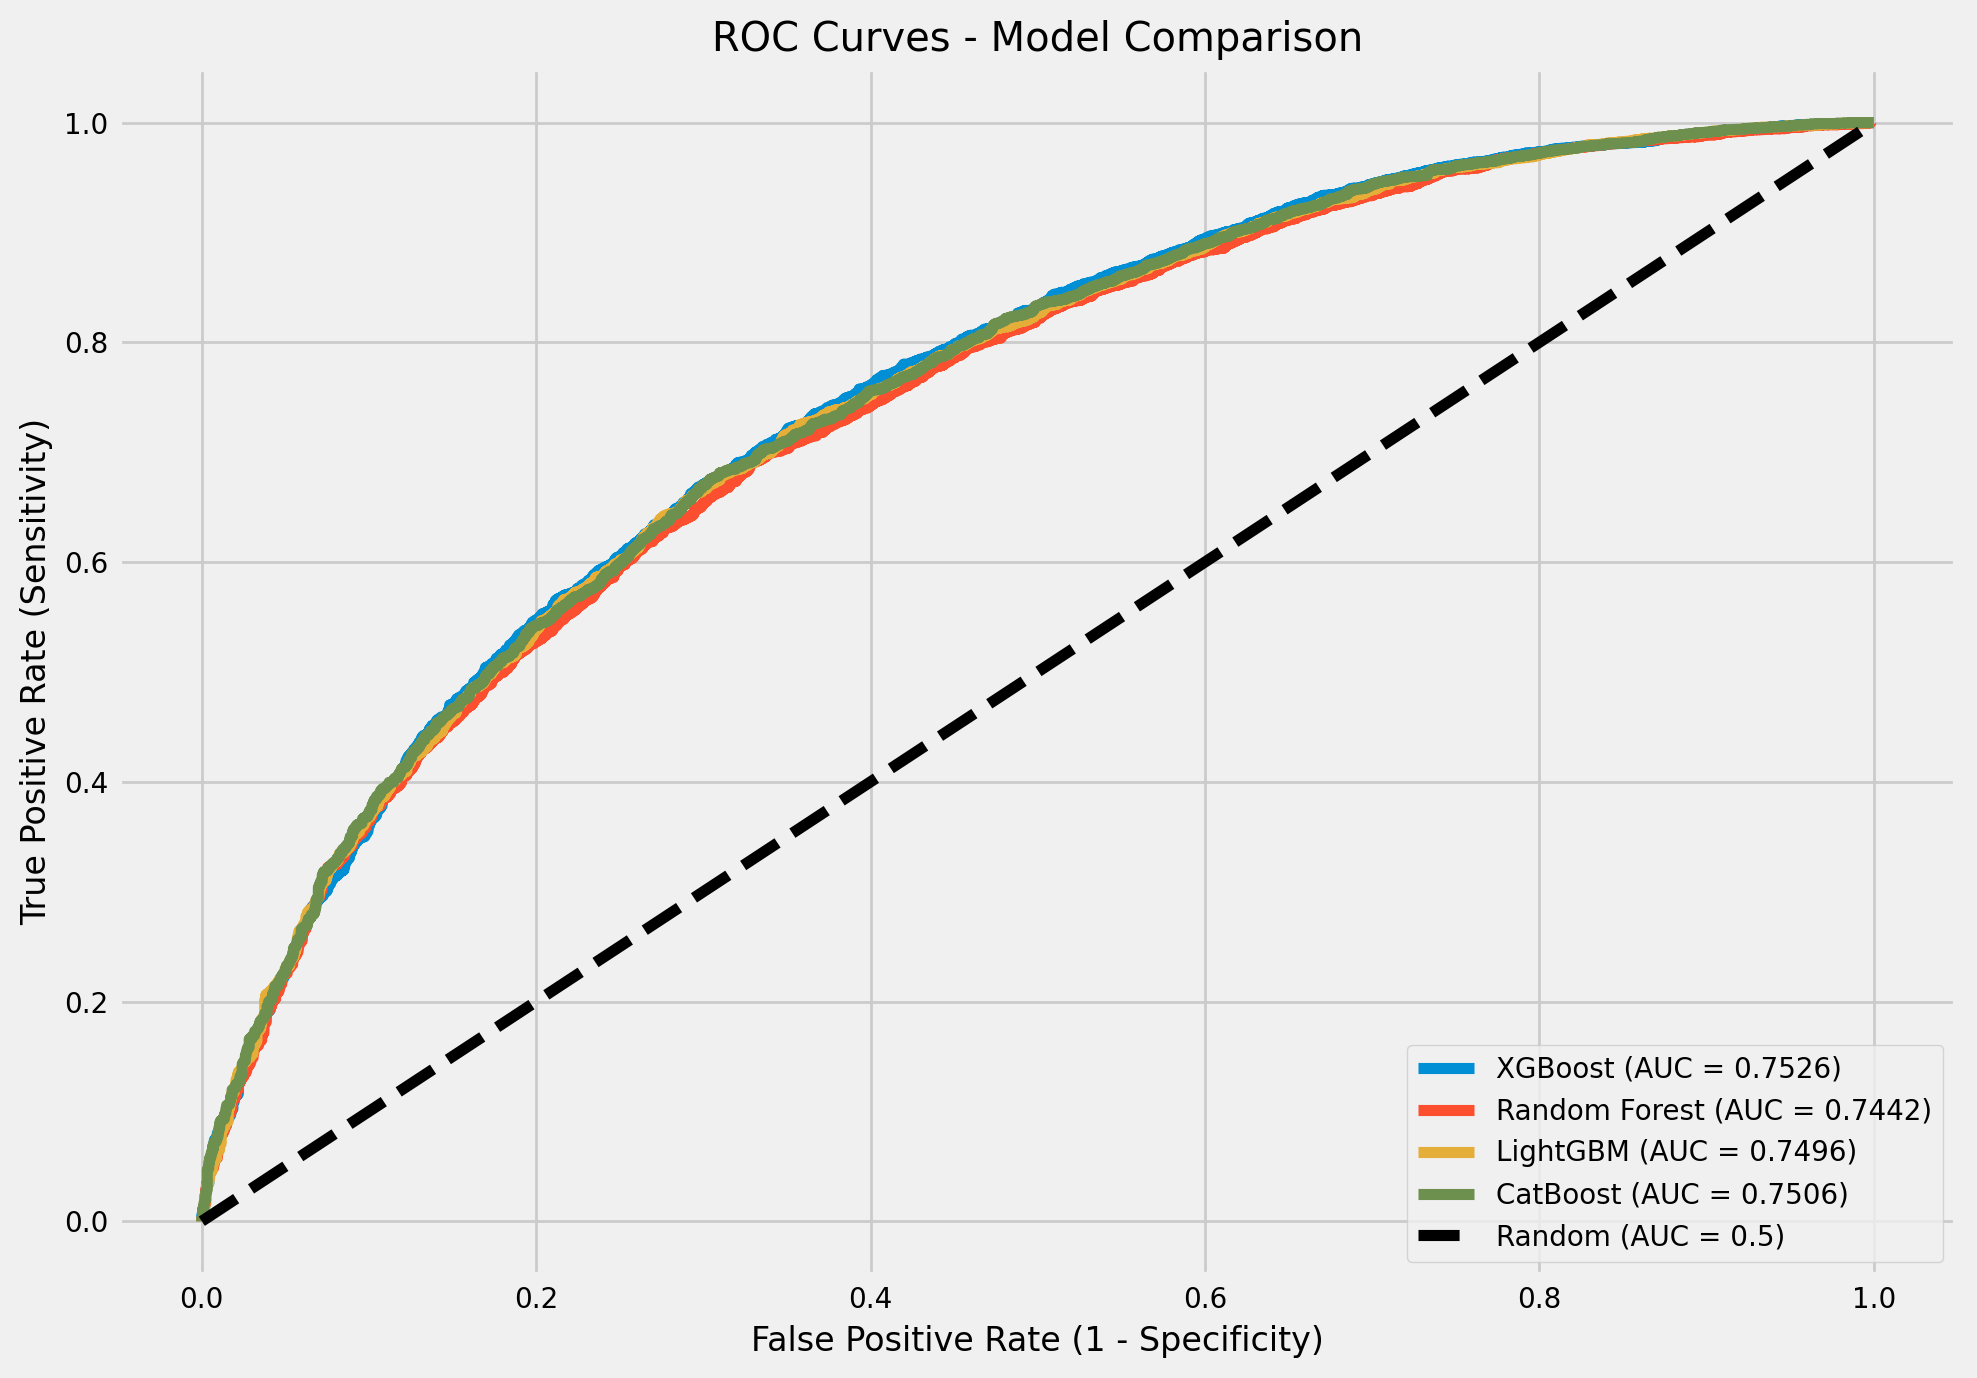

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Curvas ROC para cada modelo
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
#fpr_tabpfn, tpr_tabpfn, _ = roc_curve(y_test, y_prob_tabpfn)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {roc_auc_cat:.4f})')
#plt.plot(fpr_tabpfn, tpr_tabpfn, label=f'TABPFN (AUC = {roc_auc_tabpfn:.4f})')

# Linha de referência
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

# Rótulos e título
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# Salvar a figura em .tiff com 300 DPI
plt.savefig('roc_curves_comparison.tiff', format='tiff', dpi=300)

# Mostrar o gráfico
plt.show()


In [ ]:
# Cria a figura Plotly
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=fpr_rf, y=tpr_rf,
    mode='lines',
    name=f'Random Forest (AUC = {roc_auc_rf:.4f})',
    line=dict(color='green')
))

fig.add_trace(go.Scatter(
    x=fpr_xgb, y=tpr_xgb,
    mode='lines',
    name=f'XGBoost (AUC = {roc_auc_xgb:.4f})',
    line=dict(color='orange')
))

fig.add_trace(go.Scatter(
    x=fpr_lgb, y=tpr_lgb,
    mode='lines',
    name=f'LightGBM (AUC = {roc_auc_lgb:.4f})',
    line=dict(color='blue')
))

fig.add_trace(go.Scatter(
    x=fpr_cat, y=tpr_cat,
    mode='lines',
    name=f'CatBoost (AUC = {roc_auc_cat:.4f})',
    line=dict(color='red')
))

#fig.add_trace(go.Scatter(
#    x=fpr_tabpfn, y=tpr_tabpfn,
#    mode='lines',
#    name=f'TABPFN (AUC = {roc_auc_tabpfn:.4f})',
#    line=dict(color='brown')
#))
#

# Linha de referência
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='black', dash='dash'),
    showlegend=False
))

# Layout
fig.update_layout(
    title='ROC curve - Model Comparison',
    xaxis_title='False Positive Rate (FPR)',
    yaxis_title='True Positive Rate (TPR)',
    width=900,
    height=600
)

fig.show()

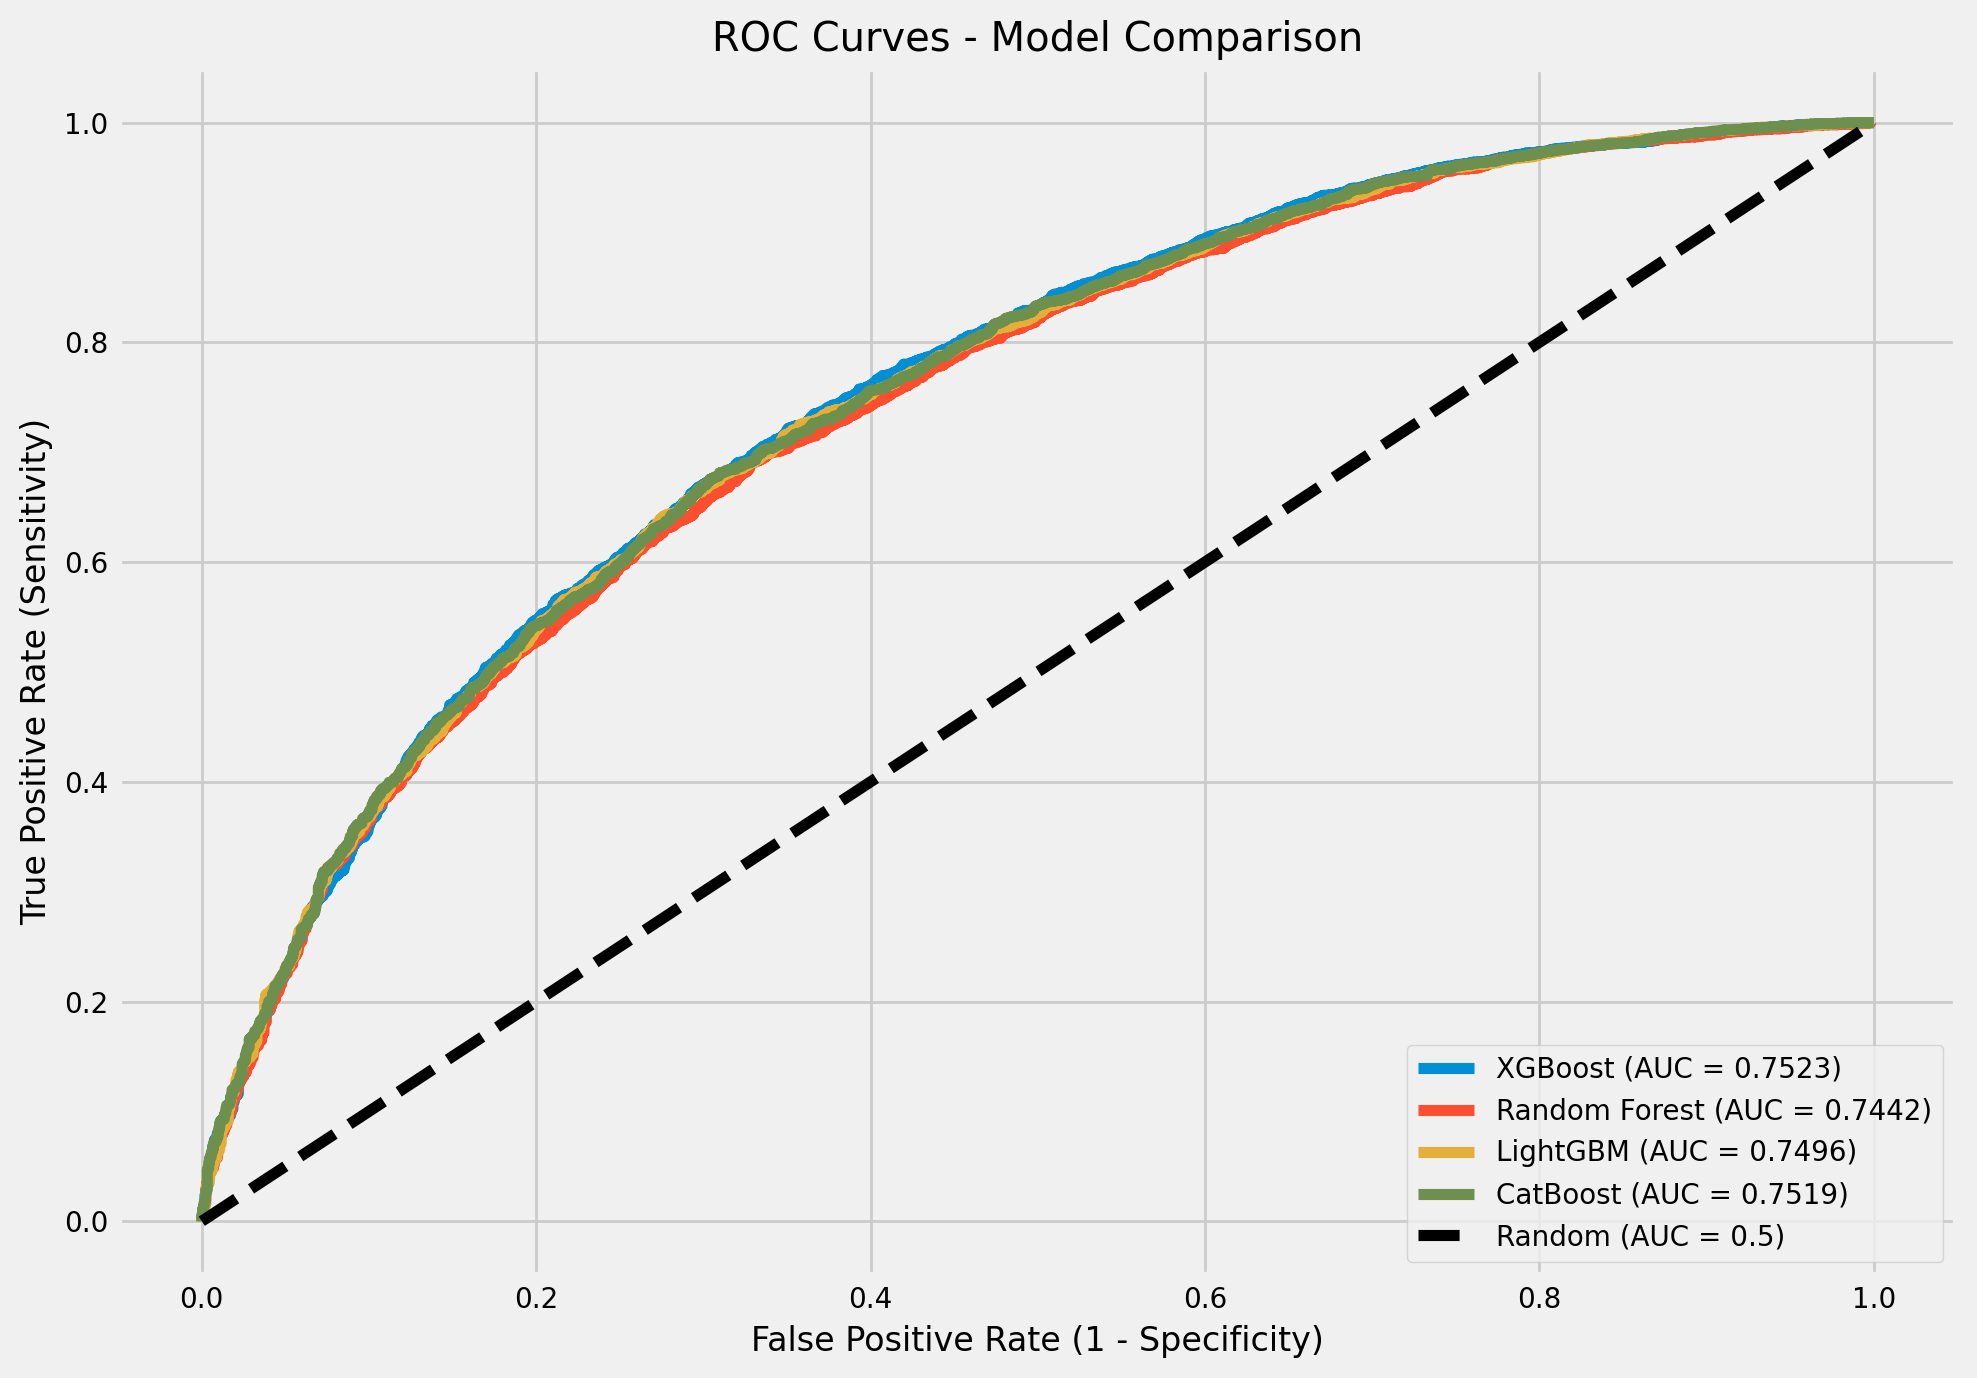

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Curvas ROC para cada modelo
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
#fpr_tabpfn, tpr_tabpfn, _ = roc_curve(y_test, y_prob_tabpfn)

# Plot
plt.figure(figsize=(10, 7))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {auc_lgb:.4f})')
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {auc_cat:.4f})')
#plt.plot(fpr_tabpfn, tpr_tabpfn, label=f'TABPFN (AUC = {auc_tabpfn:.4f})')

# Linha de referência
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5)')

# Rótulos e título
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()

# Salvar a figura em .tiff com 300 DPI
plt.savefig('roc_curves_comparison.tiff', format='tiff', dpi=300)

# Mostrar o gráfico
plt.show()


###Curva de calibraçao

In [ ]:
# Obtenção dos parametros para a curva de calibração
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=20, strategy="uniform")
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_prob_xgb, n_bins=20, strategy="uniform")
prob_true_cat, prob_pred_cat = calibration_curve(y_test, y_prob_cat, n_bins=20, strategy="uniform")
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_prob_lgb, n_bins=20, strategy="uniform")
#prob_true_tabpfn, prob_pred_tabpfn = calibration_curve(y_test, y_prob_tabpfn, n_bins=20, strategy="uniform")

In [ ]:
# Cria a figura Plotly
fig = go.Figure()

# Random Forest
fig.add_trace(go.Scatter(
    x=prob_pred_rf, y=prob_true_rf,
    mode='lines+markers',
    name='Random Forest',
    line=dict(color='green')
))

# XGBoost
fig.add_trace(go.Scatter(
    x=prob_pred_xgb, y=prob_true_xgb,
    mode='lines+markers',
    name='XGBoost',
    line=dict(color='orange')
))

# CatBoost
fig.add_trace(go.Scatter(
    x=prob_pred_cat, y=prob_true_cat,
    mode='lines+markers',
    name='CatBoost',
    line=dict(color='blue')
))

# LGBM
fig.add_trace(go.Scatter(
    x=prob_pred_lgb, y=prob_true_lgb,
    mode='lines+markers',
    name='LGBM',
    line=dict(color='red')
))

# TABPFN
#fig.add_trace(go.Scatter(
#    x=prob_pred_tabpfn, y=prob_true_tabpfn,
#    mode='lines+markers',
#    name='TABPFN',
#    line=dict(color='brown')
#))

# Linha de referência (modelo perfeitamente calibrado)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    line=dict(color='black', dash='dash'),
    showlegend=False
))

# Layout
fig.update_layout(
    title='Calibration Curve - Model Comparison',
    xaxis_title='Predicted Probability',
    yaxis_title='Observed Frequency',
    width=900,
    height=600
)

fig.show()


#4- Seleção de Variáveis e Avaliação do Melhor Modelo

---



# Seleção de Variáveis com Boruta

→ O Boruta é um algoritmo baseado em árvores que compara a importância de cada variável real com variáveis artificiais ("shadow features") criadas a partir de permutações aleatórias dos dados.

→ O algoritmo do Boruta funciona da seguinte forma:
- Cria cópias permutadas de todas as variáveis (chamadas shadow features).
- Treina um modelo de árvore com as variáveis originais + as cópias permutadas.
- Compara a importância de cada variável real com a melhor variável permutada. Ao final, a variável pode ser de três tipos:
  - Se a variável real tiver importância significativamente maior, ela é considerada Confirmada (Importante).
  - Se tiver importância significativamente menor, ela é Rejeitada (Não Importante).
  - Caso contrário, ela fica como Tentativa (Tentative) até mais iterações decidirem.

→ Documentação: https://github.com/scikit-learn-contrib/boruta_py

##Random Forest

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": rf.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
42,agravdroga_0.0,0.122526
43,agravdroga_1.0,0.114608
26,bacilosc_2_9.0,0.094304
24,bacilosc_2_0.0,0.077162
34,pop_rua_1.0,0.066765
...,...,...
55,contato_maior5_9.0,0.000240
59,escola_faixa_10.0,0.000179
62,tempo_diag_trat_14_9.0,0.000061
37,pop_imig_1.0,0.000016


In [ ]:
rf_boruta = deepcopy(rf)

# Cria o BorutaPy

boruta = BorutaPy (rf_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	21
Tentative: 	10
Rejected: 	32
Iteration: 	9 / 100
Confirmed: 	21
Tentative: 	10
Rejected: 	32
Iteration: 	10 / 100
Confirmed: 	21
Tentative: 	10
Rejected: 	32
Iteration: 	11 / 100
Confirmed: 	21
Tentative: 	10
Rejected: 	32
Iteration: 	12 / 100
Confirmed: 	21
Tentative: 	6
Rejected: 	36
Iteration: 	13 / 100
Confirmed: 	21
Tentative: 	6
Rejected: 	36
Iteration: 	14 / 100
Confirmed: 	21
Tentative: 	6
Rejected: 	36
Iteration: 	15 / 100
Confirmed: 	21
Tentative: 	6
Rejected: 	36
Iteration: 	16 / 100
Confirmed: 	23
Tentative: 	4
Re

BorutaPy(estimator=RandomForestClassifier(max_depth=15, min_samples_leaf=20,
                                          min_samples_split=np.float64(0.011369833481632412),
                                          n_estimators=46, n_jobs=-1,
                                          random_state=RandomState(MT19937) at 0x7D80401B8840),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D80401B8840, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'bacilosc_2_0.0', 'bacilosc_2_9.0', 'tratsup_at_0.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'pop_rua_0.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'escola_faixa_0.0', 'escola_faixa_1.0']
❌ Features rejeitadas: ['cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_1.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_0.0', 'bacilosc_e_1.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'cultura_es_1.0', 'cultura_es_9.0', 'bacilosc_2_1.0', 'pop_liber_0.0', 'pop_liber_1.0', 'pop_liber_9.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_9.0', 'faixa_etaria2_0.0'

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_1,1,True,False
2,cs_raca_1.0,1,True,False
3,cs_raca_2.0,1,True,False
9,agravalcoo_0.0,1,True,False
10,agravalcoo_1.0,1,True,False
8,raiox_tora_9.0,1,True,False
28,tratsup_at_1.0,1,True,False
29,tratsup_at_9.0,1,True,False
26,bacilosc_2_9.0,1,True,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (23971, 23)
Shape do X_test após Boruta: (10963, 23)

✅ Mantendo features selecionadas pelo Boruta.


In [ ]:
print(f"✅ ROC AUC do melhor modelo ({best_method_rf}): {auc_rf:.4f}")

✅ ROC AUC do melhor modelo (Optuna): 0.7442


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO
# ======================================

if best_method_rf == "Optuna":

    print("\n🚀 Executando OPTUNA...")

    import optuna

    def objective_rf(trial):

        rf_novo = RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
            max_depth=trial.suggest_int("max_depth", 5, 15),
            min_samples_split=trial.suggest_float("min_samples_split", 0.01, 0.05),
            min_samples_leaf=trial.suggest_categorical("min_samples_leaf", [5, 10, 26]),
            max_features=trial.suggest_categorical("max_features", [None, "sqrt", "log2"]),
            random_state=seed,
            n_jobs=-1
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        return cross_val_score(
            rf,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1
        ).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_rf, n_trials=50)

    best_params_rf_novo = study.best_params
    print("Melhores hiperparâmetros:", best_params_rf_novo)
    print("Melhor AUC CV:", study.best_value)

    rf_novo = RandomForestClassifier(
        **best_params_rf_novo,
        random_state=seed,
        n_jobs=-1
    )


# ======================================

elif best_method_rf == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH...")

    rf_dict = {
        'n_estimators': np.arange(200, 501, 100),
        'max_depth': np.arange(5, 15, 1),
        'min_samples_split': np.arange(0.01, 0.06, 0.01),
        'min_samples_leaf': [5, 10, 26],
        'max_features': [None, 'sqrt', 'log2']
    }

    rf_base = RandomForestClassifier(
        random_state=seed,
        n_jobs=-1
    )

    rf_novo = RandomizedSearchCV(
        estimator=rf_base,
        param_distributions=rf_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    rf_novo.fit(X_train_novo, y_train)

    best_params_rf_novo = rf_novo.best_params_
    print("Melhores hiperparâmetros:", best_params_rf_novo)

    rf_novo = rf_novo.best_estimator_


# ======================================

elif best_method_rf == "Hyperopt":

    print("\n🚀 Executando HYPEROPT...")

    from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

    space = {
        'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
        'max_depth': hp.quniform('max_depth', 5, 14, 1),
        'min_samples_split': hp.uniform('min_samples_split', 0.01, 0.05),
        'min_samples_leaf': hp.choice('min_samples_leaf', [5, 10, 26]),
        'max_features': hp.choice('max_features', [None, 'sqrt', 'log2'])
    }

    def objective(params):

        model = RandomForestClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            min_samples_split=params['min_samples_split'],
            min_samples_leaf=params['min_samples_leaf'],
            max_features=params['max_features'],
            random_state=seed,
            n_jobs=-1
        )

        score = cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        ).mean()

        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=50,
        trials=trials,
        rstate=np.random.default_rng(seed)
    )

    # Ajustar índices do hp.choice
    best_params_rf_novo = {
        'n_estimators': [200, 300, 400, 500][best['n_estimators']],
        'max_depth': int(best['max_depth']),
        'min_samples_split': best['min_samples_split'],
        'min_samples_leaf': [5, 10, 26][best['min_samples_leaf']],
        'max_features': [None, 'sqrt', 'log2'][best['max_features']]
    }

    print("Melhores hiperparâmetros:", best_params_rf_novo)

    rf_novo = RandomForestClassifier(
        **best_params_rf_novo,
        random_state=seed,
        n_jobs=-1
    )


# ======================================
# TREINAMENTO FINAL
# ======================================

rf_novo.fit(X_train_novo, y_train)

y_prob_rf = rf_novo.predict_proba(X_test_novo)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_rf}): {auc_rf:.4f}")

[I 2026-05-07 16:58:07,515] A new study created in memory with name: no-name-c7cdd206-977f-4e46-a696-749be6de3ee2



🚀 Executando OPTUNA...


[I 2026-05-07 16:58:32,832] Trial 0 finished with value: 0.7407473453140376 and parameters: {'n_estimators': 400, 'max_depth': 13, 'min_samples_split': 0.02609437178000243, 'min_samples_leaf': 5, 'max_features': None}. Best is trial 0 with value: 0.7407473453140376.
[I 2026-05-07 16:58:52,474] Trial 1 finished with value: 0.7409890146754203 and parameters: {'n_estimators': 300, 'max_depth': 13, 'min_samples_split': 0.026918399602720765, 'min_samples_leaf': 10, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.7409890146754203.
[I 2026-05-07 16:59:12,151] Trial 2 finished with value: 0.7408115219930428 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_samples_split': 0.022456344012455474, 'min_samples_leaf': 26, 'max_features': 'log2'}. Best is trial 1 with value: 0.7409890146754203.
[I 2026-05-07 16:59:33,684] Trial 3 finished with value: 0.7409239634921638 and parameters: {'n_estimators': 500, 'max_depth': 13, 'min_samples_split': 0.029473996258230065, 'min_samples_leaf'

Melhores hiperparâmetros: {'n_estimators': 400, 'max_depth': 10, 'min_samples_split': 0.016997756024330835, 'min_samples_leaf': 26, 'max_features': None}
Melhor AUC CV: 0.7411373686661055

✅ ROC AUC do melhor modelo (Optuna): 0.7366


###Modelos comparados original vs boruta

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

rf_original = RandomForestClassifier(
    **best_params_rf_completo,
    n_jobs=-1
)

rf_original.fit(X_train, y_train)

y_prob_original = rf_original.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

rf_boruta = RandomForestClassifier(
    **best_params_rf_novo,
    random_state=seed,
    n_jobs=-1
)

rf_boruta.fit(X_train_novo, y_train)

y_prob_boruta = rf_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)")
print("=============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (RandomForest)
AUC - Base Completa  : 0.7439
AUC - Após Boruta    : 0.7366

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo      AUC  N_Features
0  Base Completa  0.74388          63
1    Após Boruta  0.73662          23


##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

#### Comparação da Performance dos Modelos - curva roc

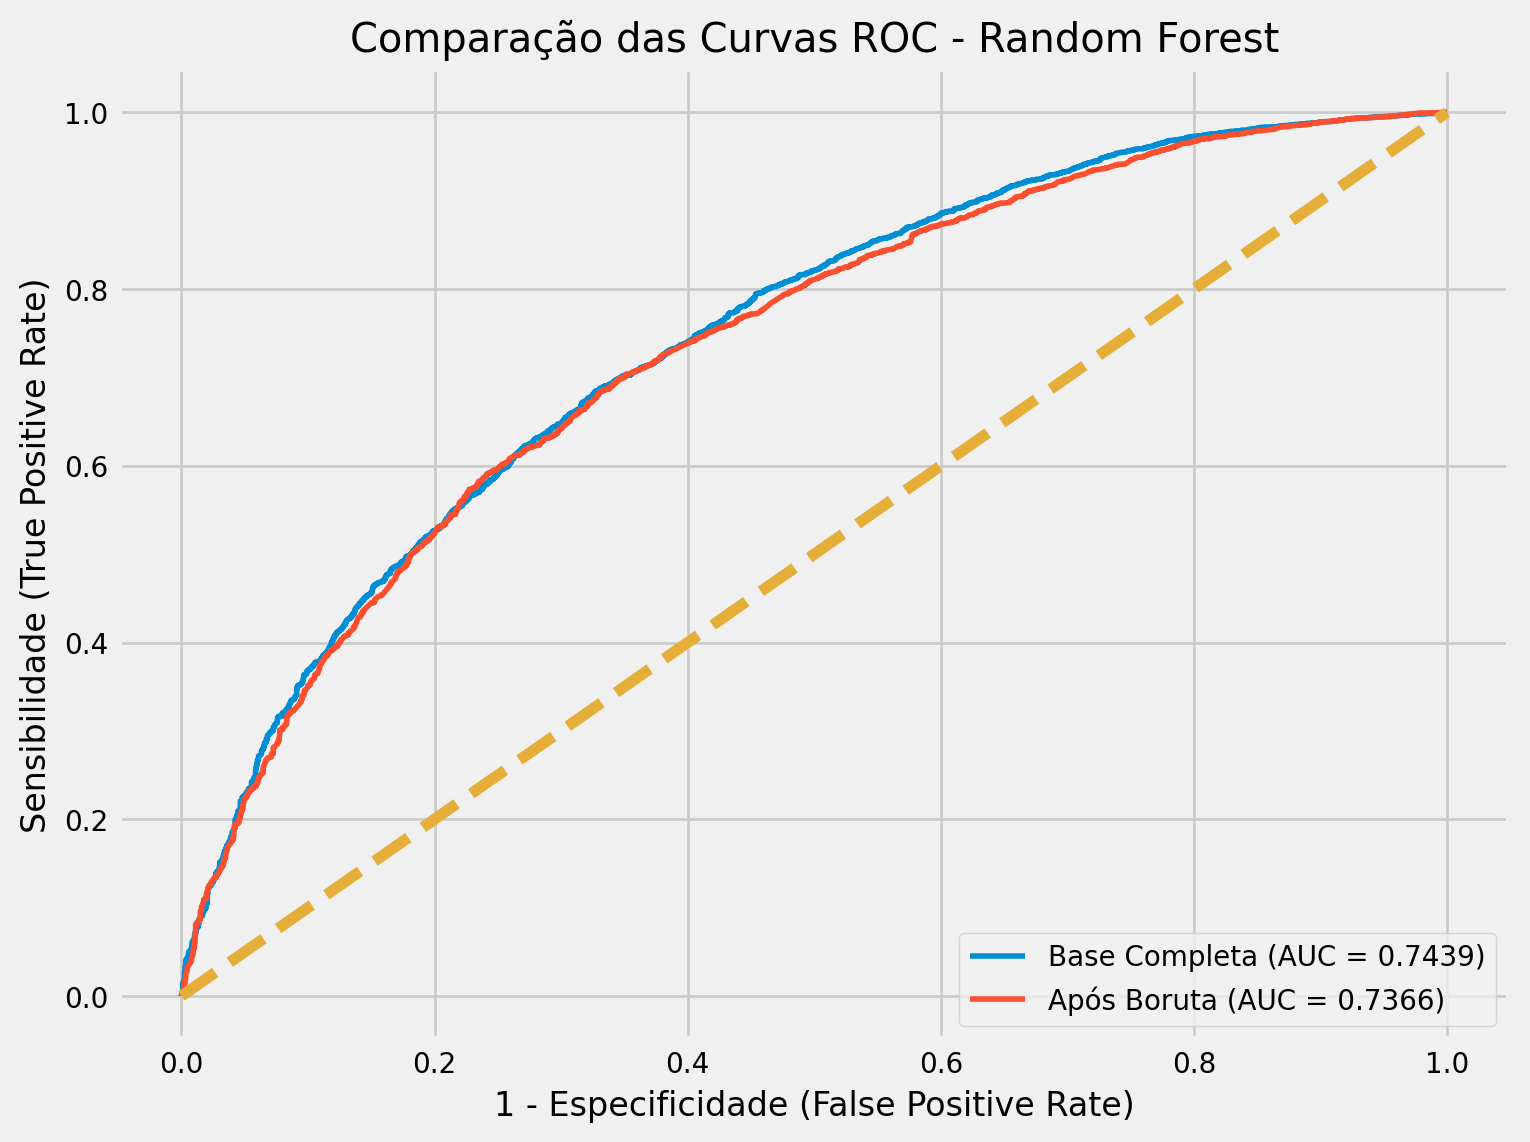

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ======================================
# CURVAS ROC
# ======================================

fpr_original, tpr_original, _ = roc_curve(y_test, y_prob_original)
fpr_boruta, tpr_boruta, _ = roc_curve(y_test, y_prob_boruta)

# ======================================
# PLOT
# ======================================

plt.figure(figsize=(8,6))

plt.plot(
    fpr_original,
    tpr_original,
    label=f'Base Completa (AUC = {auc_original:.4f})',
    linewidth=2
)

plt.plot(
    fpr_boruta,
    tpr_boruta,
    label=f'Após Boruta (AUC = {auc_boruta:.4f})',
    linewidth=2
)

# Linha aleatória
plt.plot([0,1], [0,1], linestyle='--')

# Configurações
plt.xlabel('1 - Especificidade (False Positive Rate)')
plt.ylabel('Sensibilidade (True Positive Rate)')
plt.title('Comparação das Curvas ROC - Random Forest')
plt.legend(loc='lower right')

plt.grid(True)
plt.show()

#### Comparação da Calibração do Modelo

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_rf_novo = rf_novo.predict_proba(X_test_novo)[:, 1] # Changed X_test_novo to X_test_rf_boruta

# Calibration curves
prob_true_rf, prob_pred_rf = calibration_curve(y_test, y_prob_rf, n_bins=10, strategy="uniform")
prob_true_rf_novo, prob_pred_rf_novo = calibration_curve(y_test, y_prob_rf_novo, n_bins=10, strategy="uniform")

# Creating the interactive figure
fig = go.Figure()

# Perfect line
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Original model
fig.add_trace(go.Scatter(
    x=prob_pred_rf, y=prob_true_rf,
    mode='lines+markers',
    name='RF original',
    line=dict(color='blue')
))

# Model with Boruta
fig.add_trace(go.Scatter(
    x=prob_pred_rf_novo, y=prob_true_rf_novo,
    mode='lines+markers',
    name='RF com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

##XGBoost

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": xgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
42,agravdroga_0.0,0.122948
26,bacilosc_2_9.0,0.101702
43,agravdroga_1.0,0.086401
57,escola_faixa_1.0,0.052970
34,pop_rua_1.0,0.047711
...,...,...
62,tempo_diag_trat_14_9.0,0.003245
53,contato_maior5_0.0,0.002946
47,agravtabac_9.0,0.002778
38,pop_imig_9.0,0.002591


In [ ]:
xgb_boruta = deepcopy(xgb)

# Cria o BorutaPy

boruta = BorutaPy (xgb_boruta,
                   n_estimators='auto',
                   alpha=0.05,
                   max_iter=100,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	22
Tentative: 	24
Rejected: 	17
Iteration: 	9 / 100
Confirmed: 	22
Tentative: 	24
Rejected: 	17
Iteration: 	10 / 100
Confirmed: 	22
Tentative: 	24
Rejected: 	17
Iteration: 	11 / 100
Confirmed: 	22
Tentative: 	24
Rejected: 	17
Iteration: 	12 / 100
Confirmed: 	22
Tentative: 	16
Rejected: 	25
Iteration: 	13 / 100
Confirmed: 	22
Tentative: 	16
Rejected: 	25
Iteration: 	14 / 100
Confirmed: 	22
Tentative: 	16
Rejected: 	25
Iteration: 	15 / 100
Confirmed: 	22
Tentative: 	16
Rejected: 	25
Iteration: 	16 / 100
Confirmed: 	22
Tentative: 	

BorutaPy(estimator=XGBClassifier(base_score=None, booster=None, callbacks=None,
                                 colsample_bylevel=None, colsample_bynode=None,
                                 colsample_bytree=np.float64(0.6492307718341639),
                                 device=None, early_stopping_rounds=None,
                                 enable_categorical=False, eval_metric=None,
                                 feature_types=None, feature_weights=None,
                                 gamma=np.float64(0.148381038637194),
                                 grow_policy=None, import...
                                 learning_rate=np.float64(0.07485308099155867),
                                 max_bin=None, max_cat_threshold=None,
                                 max_cat_to_onehot=None, max_delta_step=None,
                                 max_depth=3, max_leaves=None,
                                 min_child_weight=None, missing=nan,
                                 monotone_constraints=None, multi_strategy=None,
                                 n_estimators=274, n_jobs=-1,
                                 num_parallel_tree=None, ...),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D80401BB740, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'agravalcoo_1.0', 'agravdiabe_1.0', 'bacilosc_e_0.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'bacilosc_2_0.0', 'bacilosc_2_9.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'pop_liber_1.0', 'pop_rua_0.0', 'pop_rua_1.0', 'benef_gov_0.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'escola_faixa_1.0', 'tempo_diag_trat_14_0.0', 'tempo_diag_trat_14_1.0']
❌ Features rejeitadas: ['cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'cultura_es_1.0', 'bacilosc_2_1.0', 'tratsup_at_0.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_9.0', 'faixa_etaria2_9.0', 'cont

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_1,1,True,False
2,cs_raca_1.0,1,True,False
3,cs_raca_2.0,1,True,False
13,agravdiabe_1.0,1,True,False
10,agravalcoo_1.0,1,True,False
9,agravalcoo_0.0,1,True,False
8,raiox_tora_9.0,1,True,False
24,bacilosc_2_0.0,1,True,False
26,bacilosc_2_9.0,1,True,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

### Retreino do Modelo

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (23971, 31)
Shape do X_test após Boruta: (10963, 31)

✅ Mantendo features selecionadas pelo Boruta.


In [ ]:
print(f"✅ ROC AUC do melhor modelo ({best_method_xgb}): {auc_xgb:.4f}")

✅ ROC AUC do melhor modelo (Hyperopt): 0.7523


In [ ]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO
# ======================================

if best_method_xgb == "Optuna":

    print("\n🚀 Executando OPTUNA (XGBoost)...")

    import optuna

    def objective_xgb(trial):

        model = XGBClassifier(
        n_estimators=trial.suggest_int("n_estimators", 200, 500, step=100),
        max_depth=trial.suggest_int("max_depth", 3, 10),
        learning_rate=trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        gamma=trial.suggest_float("gamma", 0.0, 0.3),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 1.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1.0, 2.0),
        objective="binary:logistic",
        eval_metric="auc",
        random_state=seed,
        tree_method="hist",
        predictor="cpu_predictor",
        n_jobs=-1
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        return cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1
        ).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_xgb, n_trials=50)

    best_params_xgb_novo = study.best_params
    print("Melhores hiperparâmetros:", best_params_xgb_novo)
    print("Melhor AUC CV:", study.best_value)

    xgb_novo = XGBClassifier(
        **best_params_xgb_novo,
        random_state=seed,
        eval_metric="logloss",
        n_jobs=-1
    )


# ======================================

elif best_method_xgb == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH (XGBoost)...")

    xgb_dict = {
    'n_estimators': np.arange(200, 501, 100),           # número de árvores, de 100 a 500 com passo de 100
    'max_depth': np.arange(3, 11, 1),                   # profundidade máxima da árvore, de 3 a 10
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'gamma': np.linspace(0, 0.3, 4),                    # regularização por redução mínima da perda
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2, de 1 a 2
    }

    xgb_base = XGBClassifier(
        random_state=seed,
        eval_metric="logloss",
        n_jobs=-1
    )

    xgb_novo = RandomizedSearchCV(
        estimator=xgb_base,
        param_distributions=xgb_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    xgb_novo.fit(X_train_novo, y_train)

    best_params_xgb_novo = xgb_rs.best_params_
    print("Melhores hiperparâmetros:", best_params_xgb_novo)

    xgb_novo = xgb_rs.best_estimator_


# ======================================

elif best_method_xgb == "Hyperopt":

    print("\n🚀 Executando HYPEROPT (XGBoost)...")

    from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

    space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0.0, 0.3),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(0.001), np.log(1)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
}

    # Função objetivo
    def objective(params):
        model = XGBClassifier(
            n_estimators=params['n_estimators'],
            max_depth=params['max_depth'],
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            gamma=params['gamma'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            objective='binary:logistic',
            random_state=seed,
            tree_method='hist',
            predictor='cpu_predictor',
            n_jobs=-1
            )

        score = cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        ).mean()

        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=50,
        trials=trials,
        rstate=np.random.default_rng(seed)
    )

    best_params_xgb_novo = {
        'n_estimators': [200, 300, 400, 500][best['n_estimators']],
        'max_depth': int(best['max_depth']),
        'learning_rate': best['learning_rate'],
        'subsample': best['subsample'],
        'colsample_bytree': best['colsample_bytree'],
        'gamma': best['gamma'],
        'reg_alpha': best['reg_alpha'], # Added
        'reg_lambda': best['reg_lambda'] # Added
    }

    print("Melhores hiperparâmetros:", best_params_xgb_novo)

    xgb_novo = XGBClassifier(
        **best_params,
        random_state=seed,
        eval_metric="logloss",
        objective='binary:logistic',
        predictor='cpu_predictor',
        n_jobs=-1
    )


# ======================================
# TREINAMENTO FINAL
# ======================================

xgb_novo.fit(X_train_novo, y_train)

y_prob_xgb = xgb_novo.predict_proba(X_test_novo)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_xgb}): {auc_xgb:.4f}")


🚀 Executando HYPEROPT (XGBoost)...
100%|██████████| 50/50 [06:30<00:00,  7.81s/trial, best loss: -0.7468656366634423]
Melhores hiperparâmetros: {'n_estimators': 500, 'max_depth': 0, 'learning_rate': np.float64(0.03337097059939519), 'subsample': np.float64(0.7686456158713714), 'colsample_bytree': np.float64(0.7596748424129084), 'gamma': np.float64(0.09337978364099978), 'reg_alpha': np.float64(0.22187003471016023), 'reg_lambda': np.float64(1.5388228669618376)}

✅ ROC AUC do melhor modelo (Hyperopt): 0.7455


###Modelos comparados original vs boruta

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

xgb_original = XGBClassifier(
    **best_params_xgb_completo,
    random_state=seed,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_original.fit(X_train, y_train)

y_prob_original = xgb_original.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

xgb_boruta = XGBClassifier(
    **best_params_xgb_novo,
    random_state=seed,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_boruta.fit(X_train_novo, y_train)

y_prob_boruta = xgb_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (XGBoost)")
print("==============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (XGBoost)
AUC - Base Completa  : 0.7449
AUC - Após Boruta    : 0.6992

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.744872          63
1    Após Boruta  0.699182          31


##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

#### Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Probabilidades de cura
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

# Curva ROC - Modelo original
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

# Curva ROC - Modelo com novas features
fpr_xgb_novo, tpr_xgb_novo, _ = roc_curve(y_test, y_prob_xgb_novo)
roc_auc_xgb_novo = auc(fpr_xgb_novo, tpr_xgb_novo)

# Criando a figura interativa
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_xgb, y=tpr_xgb,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_xgb:.4f})',
    line=dict(color='blue')
))

# Modelo novo
fig.add_trace(go.Scatter(
    x=fpr_xgb_novo, y=tpr_xgb_novo,
    mode='lines',
    name=f'Modelo com boruta (AUC = {roc_auc_xgb_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC (Interativo)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


####Comparação da Calibração do Modelo

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Probabilidades de cura
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
y_prob_xgb_novo = xgb_novo.predict_proba(X_test_novo)[:, 1]

# Curvas de calibração
prob_true_xgb, prob_pred_xgb = calibration_curve(y_test, y_prob_xgb, n_bins=10, strategy="uniform")
prob_true_xgb_novo, prob_pred_xgb_novo = calibration_curve(y_test, y_prob_xgb_novo, n_bins=10, strategy="uniform")

# Criando a figura interativa
fig = go.Figure()

# Linha ideal
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_xgb, y=prob_true_xgb,
    mode='lines+markers',
    name='XGB original',
    line=dict(color='blue')
))

# Modelo com Boruta
fig.add_trace(go.Scatter(
    x=prob_pred_xgb_novo, y=prob_true_xgb_novo,
    mode='lines+markers',
    name='XGB com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


##LGBM

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": lgb.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
0,pop,1604
1,cs_sexo_1,589
34,pop_rua_1.0,556
49,faixa_etaria2_1.0,511
28,tratsup_at_1.0,497
...,...,...
17,agravdoenc_9.0,26
38,pop_imig_9.0,22
62,tempo_diag_trat_14_9.0,13
35,pop_rua_9.0,7


In [ ]:
lgb_boruta = deepcopy(lgb)

# Cria o BorutaPy

boruta = BorutaPy (lgb_boruta,
                   n_estimators='auto',
                   alpha=0.10,
                   max_iter=500,
                   verbose=2,
                   random_state=seed)

# Fit do Boruta para encontrar as features mais relevantes
boruta.fit(X_train, y_train)

A saída de streaming foi truncada nas últimas 5000 linhas.
Confirmed: 	26
Tentative: 	4
Rejected: 	33
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Warning] min_data_in_leaf is set=26, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=26
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013329 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 214
[LightGBM] [Info] Number of data points in the train set: 23971, number of used features: 60
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803888 -> initscore=1.410774
[LightGBM] [Info] Start training from score 1.410774
Iteration: 	143 / 500
Confirmed: 	26
Tentative: 	4
Rejected: 	33
[LightGBM] [Warning] min_data_in_le

BorutaPy(alpha=0.1,
         estimator=LGBMClassifier(colsample_bytree=np.float64(0.6),
                                  learning_rate=np.float64(0.01),
                                  max_depth=np.int64(10), min_data_in_leaf=26,
                                  n_estimators=77, random_state=6464,
                                  reg_alpha=np.float64(0.1),
                                  reg_lambda=np.float64(1.5),
                                  subsample=np.float64(0.6)),
         max_iter=500, n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D80401BA140, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_9.0', 'agravalcoo_0.0', 'bacilosc_e_9.0', 'cultura_es_0.0', 'cultura_es_9.0', 'bacilosc_2_0.0', 'bacilosc_2_9.0', 'tratsup_at_0.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'pop_liber_1.0', 'pop_rua_0.0', 'pop_rua_1.0', 'benef_gov_0.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'escola_faixa_0.0', 'escola_faixa_1.0']
❌ Features rejeitadas: ['cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'agravalcoo_1.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_0.0', 'bacilosc_e_1.0', 'cultura_es_1.0', 'bacilosc_2_1.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_9.0', 'faixa_etaria2_0.0', 'faixa_etaria2_9.0', 'contato_maio

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_1,1,True,False
2,cs_raca_1.0,1,True,False
3,cs_raca_2.0,1,True,False
9,agravalcoo_0.0,1,True,False
8,raiox_tora_9.0,1,True,False
23,cultura_es_9.0,1,True,False
29,tratsup_at_9.0,1,True,False
24,bacilosc_2_0.0,1,True,False
26,bacilosc_2_9.0,1,True,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (23971, 29)
Shape do X_test após Boruta: (10963, 29)

✅ Mantendo features selecionadas pelo Boruta.


In [ ]:
print(f"✅ ROC AUC do melhor modelo ({best_method_lgb}): {auc_lgb:.4f}")

✅ ROC AUC do melhor modelo (Optuna): 0.7502


In [ ]:
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO
# ======================================

if best_method_lgb == "Optuna":

    print("\n🚀 Executando OPTUNA (LightGBM)...")
    import optuna

    def objective_lgb(trial):
        model = LGBMClassifier(
        n_estimators=trial.suggest_int('n_estimators', 200, 500, step=100),
        max_depth=trial.suggest_int('max_depth', 5, 15),
        min_data_in_leaf=trial.suggest_categorical('min_data_in_leaf', [5, 10, 26]),
        learning_rate=trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        subsample=trial.suggest_float('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_float('colsample_bytree', 0.6, 1.0),
        reg_alpha=trial.suggest_loguniform('reg_alpha', 0.001, 1),
        reg_lambda=trial.suggest_float('reg_lambda', 1.0, 2.0),
        random_state=seed
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        return cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1
        ).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_lgb, n_trials=50)

    best_params_lgb_novo = study.best_params
    print("Melhores hiperparâmetros:", best_params_lgb_novo)
    print("Melhor AUC CV:", study.best_value)

    lgb_novo = LGBMClassifier(
        **best_params_lgb_novo,
        random_state=seed,
        n_jobs=-1
    )


# ======================================

elif best_method_lgb == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH (LightGBM)...")

    lgb_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 1
    'max_depth': np.arange(5, 15, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'learning_rate': np.logspace(-2, -0.7, 4),          # taxa de aprendizado, de 0.01 a 0.2 em escala logarítmica
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'colsample_bytree': np.linspace(0.6, 1.0, 3),       # proporção de features usadas por árvore
    'reg_alpha': np.logspace(-3, 0, 4),                 # regularização L1, de 0.001 a 1
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
    }

    lgb_base = LGBMClassifier(random_state=seed, n_jobs=-1)

    lgb_novo = RandomizedSearchCV(
        estimator=lgb_base,
        param_distributions=lgb_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    lgb_novo.fit(X_train_novo, y_train)

    best_params_lgb_novo = lgb_rs.best_params_
    print("Melhores hiperparâmetros:", best_params_lgb_novo)

    lgb_novo = lgb_rs.best_estimator_


# ======================================

elif best_method_lgb == "Hyperopt":

    print("\n🚀 Executando HYPEROPT (LightGBM)...")
    from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

    space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', np.arange(5, 27, 1)),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)),
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.6, 1.0),
    'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-3), np.log(1.0)),
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
    }

    def objective(params):
        model = LGBMClassifier(
            n_estimators=int(params['n_estimators']),
            max_depth=int(params['max_depth']),
            min_data_in_leaf=int(params['min_data_in_leaf']),
            learning_rate=params['learning_rate'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            random_state=seed,
            n_jobs=-1
        )

        score = cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        ).mean()

        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=50,
        trials=trials,
        rstate=np.random.default_rng(seed)
    )

    best_params_lgb_novo = {
        'n_estimators': [200, 300, 400, 500][best['n_estimators']],
        'max_depth': int(best['max_depth']),
        'min_data_in_leaf': np.arange(5, 27, 1)[best['min_data_in_leaf']], # Corrected this line
        'learning_rate': best['learning_rate'],
        'subsample': best['subsample'],
        'colsample_bytree': best['colsample_bytree'],
        'reg_alpha': best['reg_alpha'],
        'reg_lambda': best['reg_lambda']
    }

    print("Melhores hiperparâmetros:", best_params_lgb_novo)

    lgb_novo = LGBMClassifier(
        **best_params_lgb_novo,
        random_state=seed,
        n_jobs=-1
    )


# ======================================
# TREINAMENTO FINAL
# ======================================

lgb_novo.fit(X_train_novo, y_train)

y_prob_lgb = lgb_novo.predict_proba(X_test_novo)[:, 1]
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_lgb}): {auc_lgb:.4f}")

[I 2026-05-07 18:17:50,721] A new study created in memory with name: no-name-a2f8a659-fe55-4536-9725-c5ca8cc8d5ce



🚀 Executando OPTUNA (LightGBM)...


[I 2026-05-07 18:18:00,141] Trial 0 finished with value: 0.7463838630252011 and parameters: {'n_estimators': 300, 'max_depth': 15, 'min_data_in_leaf': 5, 'learning_rate': 0.04416293285780071, 'subsample': 0.6462194993531002, 'colsample_bytree': 0.6399322719000534, 'reg_alpha': 0.2214301061290965, 'reg_lambda': 1.0319299305443683}. Best is trial 0 with value: 0.7463838630252011.
[I 2026-05-07 18:18:05,901] Trial 1 finished with value: 0.7460196342044816 and parameters: {'n_estimators': 400, 'max_depth': 12, 'min_data_in_leaf': 26, 'learning_rate': 0.021579210038830777, 'subsample': 0.6530375170909322, 'colsample_bytree': 0.8549651509852698, 'reg_alpha': 0.07038983253104518, 'reg_lambda': 1.129576074361104}. Best is trial 0 with value: 0.7463838630252011.
[I 2026-05-07 18:18:08,621] Trial 2 finished with value: 0.7471596526079088 and parameters: {'n_estimators': 200, 'max_depth': 11, 'min_data_in_leaf': 26, 'learning_rate': 0.03630491143642669, 'subsample': 0.9760107261303377, 'colsample

Melhores hiperparâmetros: {'n_estimators': 400, 'max_depth': 7, 'min_data_in_leaf': 10, 'learning_rate': 0.014234158607939027, 'subsample': 0.7770521792174458, 'colsample_bytree': 0.6174764591334838, 'reg_alpha': 0.20722564453764417, 'reg_lambda': 1.070513421978995}
Melhor AUC CV: 0.7481535789042493
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003765 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 105
[LightGBM] [Info] Number of data points in the train set: 23971, number of used features: 29
[LightGBM] [Info] [binary:BoostFr

###Modelos comparados original vs boruta

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

lgb_original = LGBMClassifier(
    **best_params_lgb_completo,
    random_state=seed,
    n_jobs=-1
)

lgb_original.fit(X_train, y_train)

y_prob_original = lgb_original.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_boruta = LGBMClassifier(
    **best_params_lgb_novo,
    random_state=seed,
    n_jobs=-1
)

lgb_boruta.fit(X_train_novo, y_train)

y_prob_boruta = lgb_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (LightGBM)")
print("==============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)

[LightGBM] [Warning] min_data_in_leaf is set=19, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=19
[LightGBM] [Warning] min_data_in_leaf is set=19, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=19
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006990 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 171
[LightGBM] [Info] Number of data points in the train set: 23971, number of used features: 62
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803888 -> initscore=1.410774
[LightGBM] [Info] Start training from score 1.410774
[LightGBM] [Warning] min_data_in_leaf is set=19, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=19
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ig

##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

#### Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Probabilidades de cura
# The variables y_prob_original and y_prob_boruta were already computed in cell jJ6YMLeDoUou
# We will use them directly to avoid issues with model reassignments

# Curva ROC - Modelo original
fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_original)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

# Curva ROC - Modelo com novas features
fpr_lgb_novo, tpr_lgb_novo, _ = roc_curve(y_test, y_prob_boruta)
roc_auc_lgb_novo = auc(fpr_lgb_novo, tpr_lgb_novo)

# Criando a figura interativa
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_lgb, y=tpr_lgb,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_lgb:.4f})',
    line=dict(color='blue')
))

# Modelo novo
fig.add_trace(go.Scatter(
    x=fpr_lgb_novo, y=tpr_lgb_novo,
    mode='lines',
    name=f'Modelo com boruta (AUC = {roc_auc_lgb_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC (Interativo)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

####Comparação da Calibração do Modelo

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Probabilidades de cura
# y_prob_lgb = lgb.predict_proba(X_test)[:, 1] # This line was causing the error due to overwriting lgb
# y_prob_lgb_novo = lgb_novo.predict_proba(X_test_novo)[:, 1]

# The variables y_prob_original and y_prob_boruta were already computed in cell jJ6YMLeDoUou
# We will use them directly to avoid issues with model reassignments

# Curvas de calibração
prob_true_lgb, prob_pred_lgb = calibration_curve(y_test, y_prob_original, n_bins=10, strategy="uniform")
prob_true_lgb_novo, prob_pred_lgb_novo = calibration_curve(y_test, y_prob_boruta, n_bins=10, strategy="uniform")

# Criando a figura interativa
fig = go.Figure()

# Linha ideal
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_lgb, y=prob_true_lgb,
    mode='lines+markers',
    name='lgb original',
    line=dict(color='blue')
))

# Modelo com Boruta
fig.add_trace(go.Scatter(
    x=prob_pred_lgb_novo, y=prob_true_lgb_novo,
    mode='lines+markers',
    name='lgb com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


##CatBoost

##• Feature selection do melhor modelo (Obrigatório para árvores e boosting)

In [ ]:
pd.DataFrame({
    "variavel": X_train.columns,
    "feature_importance": cat.feature_importances_
}).sort_values(by="feature_importance", ascending=False)

,variavel,feature_importance
26,bacilosc_2_9.0,10.177951
0,pop,6.832248
24,bacilosc_2_0.0,6.746757
57,escola_faixa_1.0,6.634824
28,tratsup_at_1.0,6.503241
...,...,...
35,pop_rua_9.0,0.100904
17,agravdoenc_9.0,0.072909
38,pop_imig_9.0,0.059107
11,agravalcoo_9.0,0.035675


In [ ]:
from catboost import CatBoostClassifier
from sklearn.base import BaseEstimator
from boruta import BorutaPy

class CatBoostWrapper(BaseEstimator):
    def __init__(self, **params):
        self.params = params.copy()
        self.model = None

    def fit(self, X, y):
        # Remove 'random_state' se estiver presente para evitar conflito com CatBoost
        clean_params = self.params.copy()
        clean_params.pop('random_state', None)

        self.model = CatBoostClassifier(**clean_params)
        self.model.fit(X, y, verbose=0)
        self.feature_importances_ = self.model.get_feature_importance()
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_params(self, deep=True):
        return self.params.copy()

    def set_params(self, **params):
        self.params.update(params)
        return self


In [ ]:
cat_params = {
    **best_params_cat_completo,  # seus melhores parâmetros finais
    'random_state': seed, # Corrected syntax
    'eval_metric': "AUC", # Corrected syntax
    'verbose': 0 # Corrected syntax
}

cat_boruta = CatBoostWrapper(**cat_params)

boruta = BorutaPy(
    estimator=cat_boruta,
    n_estimators='auto',
    alpha=0.05,
    max_iter=100,
    verbose=2,
    random_state=42         # ☢️ Só o Boruta usa isso — agora está seguro
)

# Importante: X e y devem ser arrays NumPy
boruta.fit(X_train.values, y_train.values)


Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	63
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	18
Tentative: 	14
Rejected: 	31
Iteration: 	9 / 100
Confirmed: 	18
Tentative: 	14
Rejected: 	31
Iteration: 	10 / 100
Confirmed: 	18
Tentative: 	14
Rejected: 	31
Iteration: 	11 / 100
Confirmed: 	18
Tentative: 	14
Rejected: 	31
Iteration: 	12 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	31
Iteration: 	13 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	31
Iteration: 	14 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	31
Iteration: 	15 / 100
Confirmed: 	19
Tentative: 	13
Rejected: 	31
Iteration: 	16 / 100
Confirmed: 	20
Tentative: 	

BorutaPy(estimator=CatBoostWrapper(eval_metric='AUC', max_depth=np.int64(5),
                                   min_data_in_leaf=np.int64(26),
                                   n_estimators=144,
                                   random_state=RandomState(MT19937) at 0x7D8035E85F40,
                                   reg_lambda=np.float64(1.402679718749928),
                                   subsample=np.float64(0.8636357417648474),
                                   verbose=0),
         n_estimators='auto',
         random_state=RandomState(MT19937) at 0x7D8035E85F40, verbose=2)

In [ ]:
# Features confirmadas
confirmed_features = X_train.columns[boruta.support_].to_list()

# Features rejeitadas
rejected_features = X_train.columns[~(boruta.support_ | boruta.support_weak_)].to_list()

# Features tentativas
tentative_features = X_train.columns[boruta.support_weak_].to_list()

print("✅ Features confirmadas (importantes):", confirmed_features)
print("❌ Features rejeitadas:", rejected_features)
print("❓ Features tentativas:", tentative_features)

✅ Features confirmadas (importantes): ['pop', 'cs_sexo_1', 'cs_raca_1.0', 'cs_raca_2.0', 'raiox_tora_9.0', 'agravalcoo_1.0', 'agravdiabe_1.0', 'bacilosc_e_0.0', 'cultura_es_0.0', 'bacilosc_2_0.0', 'bacilosc_2_9.0', 'tratsup_at_1.0', 'tratsup_at_9.0', 'pop_liber_1.0', 'pop_rua_1.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_0.0', 'agravtabac_1.0', 'faixa_etaria2_1.0', 'faixa_etaria2_2.0', 'faixa_etaria2_3.0', 'escola_faixa_1.0']
❌ Features rejeitadas: ['cs_raca_4.0', 'cs_raca_9.0', 'raiox_tora_0.0', 'raiox_tora_1.0', 'agravalcoo_0.0', 'agravalcoo_9.0', 'agravdiabe_0.0', 'agravdiabe_9.0', 'agravdoenc_0.0', 'agravdoenc_1.0', 'agravdoenc_9.0', 'bacilosc_e_1.0', 'bacilosc_e_9.0', 'cultura_es_1.0', 'cultura_es_9.0', 'bacilosc_2_1.0', 'tratsup_at_0.0', 'pop_liber_0.0', 'pop_liber_9.0', 'pop_rua_0.0', 'pop_rua_9.0', 'pop_imig_0.0', 'pop_imig_1.0', 'pop_imig_9.0', 'benef_gov_0.0', 'benef_gov_1.0', 'benef_gov_9.0', 'agravdroga_9.0', 'agravtabac_9.0', 'faixa_etaria2_0.0', 'faixa_etaria2_9.0

In [ ]:
# Mostrar ranking de importância calculado pelo Boruta
feactures_ranking = pd.DataFrame({
    "variavel": X_train.columns,
    "rank": boruta.ranking_,
    "confirmada": boruta.support_,
    "tentativa": boruta.support_weak_
}).sort_values(by="rank", ascending=True)

# Print ranking
feactures_ranking.head(20)

,variavel,rank,confirmada,tentativa
0,pop,1,True,False
1,cs_sexo_1,1,True,False
2,cs_raca_1.0,1,True,False
3,cs_raca_2.0,1,True,False
10,agravalcoo_1.0,1,True,False
13,agravdiabe_1.0,1,True,False
8,raiox_tora_9.0,1,True,False
18,bacilosc_e_0.0,1,True,False
31,pop_liber_1.0,1,True,False
24,bacilosc_2_0.0,1,True,False


##• Retreino do melhor modelo com base nas novas features (Obrigatório para árvores e boosting)

In [ ]:
# ===============================
# Seleção inicial (Boruta)
# ===============================
selected_features = confirmed_features + tentative_features

X_train_novo = X_train[selected_features].copy()
X_test_novo = X_test[selected_features].copy()

print("Shape do X_train após Boruta:", X_train_novo.shape)
print("Shape do X_test após Boruta:", X_test_novo.shape)

# ===============================
# Verificação automática
# ===============================
if X_train_novo.shape[1] < 10:
    print("\n⚠ Menos de 10 features selecionadas. Usando Top 20 do ranking.")

    # Selecionar top 20 do ranking
    top_20_features = feactures_ranking['variavel'].head(20).tolist()

    X_train_novo = X_train[top_20_features].copy()
    X_test_novo = X_test[top_20_features].copy()

    print("Novo shape com Top 20 features:")
    print("Shape do X_train:", X_train_novo.shape)
    print("Shape do X_test:", X_test_novo.shape)

else:
    print("\n✅ Mantendo features selecionadas pelo Boruta.")

Shape do X_train após Boruta: (23971, 25)
Shape do X_test após Boruta: (10963, 25)

✅ Mantendo features selecionadas pelo Boruta.


### Retreino do Modelo

In [ ]:
print(f"✅ ROC AUC do melhor modelo ({best_method_cat}): {auc_cat:.4f}")

✅ ROC AUC do melhor modelo (Optuna): 0.7519


In [ ]:
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import roc_auc_score
import optuna
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

# ======================================
# SELEÇÃO AUTOMÁTICA DO MÉTODO - CatBoost
# ======================================

if best_method_cat == "Optuna":

    print("\n🚀 Executando OPTUNA (CatBoost)...")

    def objective_cat(trial):
        model = CatBoostClassifier(
        iterations=trial.suggest_int("n_estimators", 200, 500, step=100),
        depth=trial.suggest_int("max_depth", 3, 10),
        min_data_in_leaf=trial.suggest_categorical(
            "min_data_in_leaf", [5, 10, 26]
        ),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        l2_leaf_reg=trial.suggest_float("reg_lambda", 1.0, 2.0),
        eval_metric="AUC",
        random_state=seed,
        verbose=0
        )

        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        return cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1
        ).mean()

    study = optuna.create_study(direction="maximize")
    study.optimize(objective_cat, n_trials=50)

    best_params_cat_novo = study.best_params
    print("Melhores hiperparâmetros:", best_params_cat_novo)
    print("Melhor AUC CV:", study.best_value)

    cat_novo = CatBoostClassifier(
        **best_params_cat_novo,
        random_state=seed,
        eval_metric="AUC",
        verbose=0
    )


elif best_method_cat == "RandomSearch":

    print("\n🚀 Executando RANDOM SEARCH (CatBoost)...")

    cat_dict = {
    'n_estimators': np.arange(200, 501, 100),  # número de árvores, de 100 a 500
    'max_depth': np.arange(3, 11, 1),  # profundidade máxima da árvore, de 3 a 10
    'min_data_in_leaf': [5,26,10],  # número mínimo de observaçoes em uma folha
    'subsample': np.linspace(0.6, 1.0, 3),              # proporção de amostras usadas por árvore
    'reg_lambda': np.linspace(1, 2, 3)                  # regularização L2
    }

    cat_base = CatBoostClassifier(random_state=seed, eval_metric="AUC", verbose=0)

    cat_novo = RandomizedSearchCV(
        estimator=cat_base,
        param_distributions=cat_dict,
        scoring="roc_auc",
        cv=5,
        n_iter=20,
        n_jobs=-1,
        random_state=seed
    )

    cat_novo.fit(X_train_novo, y_train)

    best_params_cat_novo = cat_rs.best_params_
    print("Melhores hiperparâmetros:", best_params_cat_novo)

    cat_novo = cat_rs.best_estimator_


elif best_method_cat == "Hyperopt":

    print("\n🚀 Executando HYPEROPT (CatBoost)...")

    space = {
    'n_estimators': hp.choice('n_estimators', [200, 300, 400, 500]),
    'max_depth': hp.choice('max_depth', np.arange(3, 11, 1).tolist()),
    'min_data_in_leaf': hp.choice('min_data_in_leaf', [5, 10, 26]),
    'learning_rate': hp.loguniform('learning_rate', np.log(0.01), np.log(0.2)), # Added
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'colsample_bylevel': hp.uniform('colsample_bylevel', 0.6, 1.0), # Added
    'reg_lambda': hp.uniform('reg_lambda', 1.0, 2.0)
    }

    def objective(params):
        model = CatBoostClassifier(
            iterations=params['n_estimators'], # Corrected key
            depth=int(params['max_depth']), # Corrected key
            learning_rate=params['learning_rate'], # Added
            subsample=params['subsample'],
            colsample_bylevel=params['colsample_bylevel'], # Added
            l2_leaf_reg=params['reg_lambda'], # Corrected key
            min_data_in_leaf=params['min_data_in_leaf'], # Added
            random_state=seed,
            eval_metric="AUC",
            verbose=0
        )

        score = cross_val_score(
            model,
            X_train_novo,
            y_train,
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        ).mean()

        return {'loss': -score, 'status': STATUS_OK}

    trials = Trials()
    best = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=50,
        trials=trials,
        rstate=np.random.default_rng(seed)
    )

    best_params_cat_novo = {
        'iterations': [200, 300, 400, 500][best['n_estimators']],
        'depth': list(np.arange(3, 11, 1))[best['max_depth']], # map max_depth from choice index
        'min_data_in_leaf': [5, 10, 26][best['min_data_in_leaf']], # map min_data_in_leaf from choice index
        'learning_rate': best['learning_rate'],
        'subsample': best['subsample'],
        'colsample_bylevel': best['colsample_bylevel'],
        'l2_leaf_reg': best['reg_lambda']
    }

    print("Melhores hiperparâmetros:", best_params_cat_novo)

    cat_novo = CatBoostClassifier(
        **best_params_cat_novo,
        random_state=seed,
        eval_metric="AUC",
        verbose=0
    )


# ======================================
# TREINAMENTO FINAL
# ======================================

cat_novo.fit(X_train_novo, y_train)

y_prob_cat = cat_novo.predict_proba(X_test_novo)[:, 1]
auc_cat = roc_auc_score(y_test, y_prob_cat)

print(f"\n✅ ROC AUC do melhor modelo ({best_method_cat}): {auc_cat:.4f}")

[I 2026-05-07 17:40:18,668] A new study created in memory with name: no-name-3d4396f8-d974-4efc-af05-410deeea2b68



🚀 Executando OPTUNA (CatBoost)...


[I 2026-05-07 17:40:40,540] Trial 0 finished with value: 0.7503456961184672 and parameters: {'n_estimators': 500, 'max_depth': 4, 'min_data_in_leaf': 10, 'subsample': 0.8962481607989194, 'reg_lambda': 1.3902317393893324}. Best is trial 0 with value: 0.7503456961184672.
[I 2026-05-07 17:42:48,112] Trial 1 finished with value: 0.7279178062570973 and parameters: {'n_estimators': 500, 'max_depth': 10, 'min_data_in_leaf': 26, 'subsample': 0.7053760667666752, 'reg_lambda': 1.8460848956441858}. Best is trial 0 with value: 0.7503456961184672.
[I 2026-05-07 17:43:09,441] Trial 2 finished with value: 0.7489340257823753 and parameters: {'n_estimators': 300, 'max_depth': 7, 'min_data_in_leaf': 10, 'subsample': 0.8469484082857974, 'reg_lambda': 1.8059709035706653}. Best is trial 0 with value: 0.7503456961184672.
[I 2026-05-07 17:43:52,397] Trial 3 finished with value: 0.7429821538944673 and parameters: {'n_estimators': 500, 'max_depth': 8, 'min_data_in_leaf': 26, 'subsample': 0.7352521087293211, 'r

Melhores hiperparâmetros: {'n_estimators': 400, 'max_depth': 5, 'min_data_in_leaf': 26, 'subsample': 0.8385388188144708, 'reg_lambda': 1.606006394068913}
Melhor AUC CV: 0.7508061183828127

✅ ROC AUC do melhor modelo (Optuna): 0.7495


###Modelos comparados original vs boruta

In [ ]:
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd

# ======================================
# TREINAR MODELO NA BASE ORIGINAL
# ======================================

cat_original = CatBoostClassifier(
    **best_params_cat_completo,  # seus melhores parâmetros finais
    eval_metric="AUC",
    verbose=0
)

cat_original.fit(X_train, y_train)

y_prob_original = cat_original.predict_proba(X_test)[:, 1]
auc_original = roc_auc_score(y_test, y_prob_original)


# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

cat_boruta = CatBoostClassifier(
    **best_params_cat_novo,  # seus melhores parâmetros após Boruta
    eval_metric="AUC",
    verbose=0
)

cat_boruta.fit(X_train_novo, y_train)

y_prob_boruta = cat_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)


# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO FINAL DOS MODELOS (CatBoost)")
print("=============================")
print(f"AUC - Base Completa  : {auc_original:.4f}")
print(f"AUC - Após Boruta    : {auc_boruta:.4f}")

if auc_boruta > auc_original:
    print("\n🏆 Melhor modelo: BORUTA")
elif auc_original > auc_boruta:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")


# ======================================
# TABELA RESUMO
# ======================================

df_comparacao = pd.DataFrame({
    "Modelo": ["Base Completa", "Após Boruta"],
    "AUC": [auc_original, auc_boruta],
    "N_Features": [X_train.shape[1], X_train_novo.shape[1]]
})

print("\nResumo Final:")
print(df_comparacao)


📊 COMPARAÇÃO FINAL DOS MODELOS (CatBoost)
AUC - Base Completa  : 0.7503
AUC - Após Boruta    : 0.7499

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.750331          63
1    Após Boruta  0.749910          25


##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

####Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# Probabilities of cure
y_prob_cat = cat.predict_proba(X_test)[:, 1]

# Retrain cat_novo on the selected features
cat_novo.fit(X_train_novo, y_train)

# Probabilities of cure for the model with new features
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]

# Curva ROC - Modelo original
fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

# Curva ROC - Modelo com novas features
fpr_cat_novo, tpr_cat_novo, _ = roc_curve(y_test, y_prob_cat_novo)
roc_auc_cat_novo = auc(fpr_cat_novo, tpr_cat_novo)

# Criando a figura interativa
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_cat, y=tpr_cat,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_cat:.4f})',
    line=dict(color='blue')
))

# Modelo novo
fig.add_trace(go.Scatter(
    x=fpr_cat_novo, y=tpr_cat_novo,
    mode='lines',
    name=f'Modelo com boruta (AUC = {roc_auc_cat_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC (Interativo)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

##• Avaliação do modelo final com curva de calibração

####Comparação da Calibração dos Modelos

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# Modelo original
y_prob_cat = cat.predict_proba(X_test)[:, 1]
prob_true_cat, prob_pred_cat = calibration_curve(y_test, y_prob_cat, n_bins=10, strategy="uniform")

# Modelo novo (com Boruta)
cat_novo.fit(X_train_novo, y_train)
y_prob_cat_novo = cat_novo.predict_proba(X_test_novo)[:, 1]
prob_true_cat_novo, prob_pred_cat_novo = calibration_curve(y_test, y_prob_cat_novo, n_bins=10, strategy="uniform")

# Criando a figura interativa
fig = go.Figure()

# Linha ideal (calibração perfeita)
fig.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Perfeita',
    line=dict(color='gray', dash='dash')
))

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_cat, y=prob_true_cat,
    mode='lines+markers',
    name='Modelo original',
    line=dict(color='blue')
))

# Modelo novo (Boruta)
fig.add_trace(go.Scatter(
    x=prob_pred_cat_novo, y=prob_true_cat_novo,
    mode='lines+markers',
    name='Modelo com Boruta',
    line=dict(color='green')
))

# Layout
fig.update_layout(
    title='Curvas de Calibração (Interativo)',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Frequência observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()


#TABPFN

In [ ]:
# Modelo TabPFN com configuração de ensemble
tabpfn=TabPFNClassifier(random_state=seed,ignore_pretraining_limits=True)# para rodar mais de 1000 amostras

#Ajuste da base de treino para rodar o tabpfn (com 1000 amostras, proporcionais)
df_train_tabpfn = df_train.copy()
df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)  # agrupa pelo desfecho
    .apply(lambda x: x.sample(int(1000 * len(x) / len(df_train_tabpfn)), random_state=seed, replace=True))
    .reset_index(drop=True)
)
X_train_tabpfn = df_train_tabpfn.drop(columns = "cura")
y_train_tabpfn = df_train_tabpfn.cura

# Ajuste direto (fit) — sem busca de hiperparâmetros
tabpfn.fit(X_train_tabpfn, y_train_tabpfn)


TabPFNClassifier(ignore_pretraining_limits=True, random_state=42)

In [ ]:
from tabpfn import TabPFNClassifier
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

# ======================================
# MODELO TABPFN (Base estimator)
# ======================================

tabpfn = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True  # permite >1000 amostras
)

# ======================================
# AJUSTE DA BASE (máx ~1000 amostras balanceadas) - Re-executing for clarity
# This part is already done in cell 5ISR0qqD8lOd, but ensuring variables are fresh.
# ======================================

df_train_tabpfn = df_train.copy()

df_train_tabpfn = (
    df_train_tabpfn
    .groupby('cura', group_keys=False)
    .apply(lambda x: x.sample(
        int(1000 * len(x) / len(df_train_tabpfn)),
        random_state=seed,
        replace=True
    ))
    .reset_index(drop=True)
)

X_train_tabpfn = df_train_tabpfn.drop(columns="cura")
y_train_tabpfn = df_train_tabpfn["cura"]

# ======================================
# Feature Selection: Using previously determined top_20_features
# The RFE approach is not compatible with TabPFNClassifier.
# The 'top_20_features' variable was determined in prior cells
# (e.g., based on Boruta for CatBoost, and used to prepare X_train_novo in 5ISR0qqD8lOd)
# ======================================

# Ensure 'feactures_ranking' is sorted and 'top_20_features' is defined here
# This relies on 'feactures_ranking' being defined in a previous cell (e.g., vQ-XghlfdYfw)
if 'feactures_ranking' in locals() or 'feactures_ranking' in globals():
    feactures_ranking_sorted = feactures_ranking.sort_values(by="rank", ascending=True)
    top_20_features = feactures_ranking_sorted["variavel"].head(20).tolist()
    print("Pre-defined top 20 features for TabPFN:", top_20_features)
else:
    # Fallback if feactures_ranking is not defined, though it should be if previous cells were run.
    print("Warning: 'feactures_ranking' not found. Using a default list for top_20_features.")
    top_20_features = ['cs_sexo_1', 'agravalcoo_1.0', 'tratsup_at_9.0', 'cultura_es_9.0', 'tratsup_at_0.0', 'bacilosc_2_9.0', 'escola_faixa_1.0', 'agravtabac_1.0', 'pop', 'faixa_etaria2_1.0', 'bacilosc_2_0.0', 'pop_rua_1.0', 'agravalcoo_0.0', 'benef_gov_9.0', 'faixa_etaria2_0.0', 'benef_gov_0.0', 'bacilosc_2_1.0', 'escola_faixa_9.0', 'contato_maior5_9.0', 'agravdroga_1.0']

selected_features = top_20_features
X_train_tabpfn_selected = X_train_tabpfn[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

print("\n✅ Variáveis selecionadas (usando top 20):")
print(selected_features)

# ======================================
# TREINAR MODELO FINAL COM VARIÁVEIS SELECIONADAS
# ======================================

tabpfn_final = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

tabpfn_final.fit(X_train_tabpfn_selected, y_train_tabpfn)

# ======================================
# AVALIAÇÃO
# ======================================

y_prob_tabpfn = tabpfn_final.predict_proba(X_test_selected)[:, 1]
auc_tabpfn = roc_auc_score(y_test, y_prob_tabpfn)

print(f"\n✅ ROC AUC (TabPFN com variáveis selecionadas): {auc_tabpfn:.4f}")

# ======================================
# RANKING DAS VARIÁVEIS (No longer applicable as RFE is removed)
# ======================================
# The ranking for TabPFN with RFE is not feasible due to model limitations.
# We are using the 'top_20_features' list as our selected features.

Pre-defined top 20 features for TabPFN: ['pop', 'cs_sexo_1', 'agravalcoo_0.0', 'tratsup_at_1.0', 'bacilosc_2_0.0', 'bacilosc_2_9.0', 'tratsup_at_9.0', 'pop_rua_1.0', 'contato_maior5_1.0', 'escola_faixa_1.0', 'tempo_diag_trat_14_9.0', 'agravtabac_0.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_1.0', 'agravalcoo_1.0', 'bacilosc_e_0.0', 'cs_raca_4.0', 'pop_imig_1.0']

✅ Variáveis selecionadas (usando top 20):
['pop', 'cs_sexo_1', 'agravalcoo_0.0', 'tratsup_at_1.0', 'bacilosc_2_0.0', 'bacilosc_2_9.0', 'tratsup_at_9.0', 'pop_rua_1.0', 'contato_maior5_1.0', 'escola_faixa_1.0', 'tempo_diag_trat_14_9.0', 'agravtabac_0.0', 'benef_gov_9.0', 'agravdroga_0.0', 'agravdroga_1.0', 'agravtabac_1.0', 'agravalcoo_1.0', 'bacilosc_e_0.0', 'cs_raca_4.0', 'pop_imig_1.0']

✅ ROC AUC (TabPFN com variáveis selecionadas): 0.6841


In [ ]:
# ======================================
# GARANTIR QUE AS FEATURES EXISTEM NA BASE
# ======================================

selected_features = [f for f in selected_features if f in X_train_tabpfn.columns]

print("\nTotal de variáveis válidas:", len(selected_features))

X_train_tabpfn_selected = X_train_tabpfn[selected_features].copy()
X_test_selected = X_test[selected_features].copy()

# ======================================
# TREINAR MODELO NA BASE COMPLETA (para comparação)
# ======================================

tabpfn_full = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)

tabpfn_full.fit(X_train_tabpfn, y_train_tabpfn)

y_prob_full = tabpfn_full.predict_proba(X_test[X_train_tabpfn.columns])[:, 1]
auc_full = roc_auc_score(y_test, y_prob_full)

# ======================================
# COMPARAÇÃO FINAL
# ======================================

print("\n==============================")
print("📊 COMPARAÇÃO TABPFN")
print("==============================")
print(f"AUC - Base Completa : {auc_full:.4f}")
print(f"AUC - Top 20        : {auc_tabpfn:.4f}")

if auc_tabpfn > auc_full:
    print("\n🏆 Melhor modelo: TOP 20 VARIÁVEIS")
elif auc_full > auc_tabpfn:
    print("\n🏆 Melhor modelo: BASE COMPLETA")
else:
    print("\n🤝 Empate técnico")

# ======================================
# TABELA RESUMO
# ======================================

df_comparacao_tabpfn = pd.DataFrame({
    "Modelo": ["Base Completa", "Top 20"],
    "AUC": [auc_full, auc_tabpfn],
    "N_Features": [X_train_tabpfn.shape[1], len(selected_features)]
})

print("\nResumo Final:")
print(df_comparacao_tabpfn)


Total de variáveis válidas: 20

📊 COMPARAÇÃO TABPFN
AUC - Base Completa : 0.7015
AUC - Top 20        : 0.6841

🏆 Melhor modelo: BASE COMPLETA

Resumo Final:
          Modelo       AUC  N_Features
0  Base Completa  0.701522          63
1         Top 20  0.684115          20


In [ ]:
# Ajuste da base apenas com as top 20 features
X_train_novo = X_train[top_20_features].copy()
X_test_novo  = X_test[top_20_features].copy()

print("Shape X_train_novo:", X_train_novo.shape)
print("Shape X_test_novo:", X_test_novo.shape)


Shape X_train_novo: (2933, 20)
Shape X_test_novo: (1101, 20)


### Retreino do Modelo

In [ ]:
# ================================================================
# 1️⃣ Ajuste da base apenas com as top 20 features
# ================================================================
X_train_novo = X_train[top_20_features].copy()
X_test_novo  = X_test[top_20_features].copy()

print("Shape X_train_novo:", X_train_novo.shape)
print("Shape X_test_novo:", X_test_novo.shape)


# ================================================================
# 2️⃣ Criar dataframe reduzido (top 20 + target)
# ================================================================
df_train_reduzido = pd.concat([X_train_novo, y_train], axis=1)


# ================================================================
# 3️⃣ Amostragem proporcional (~1000 amostras)
# ================================================================
df_train_tabpfn = (
    df_train_reduzido
    .groupby('cura', group_keys=False)
    .apply(lambda x: x.sample(
        int(1000 * len(x) / len(df_train_reduzido)),
        random_state=seed,
        replace=True # Added replace=True to allow oversampling
    ))
    .reset_index(drop=True)
)

X_train_tabpfn = df_train_tabpfn[top_20_features].copy()
y_train_tabpfn = df_train_tabpfn["cura"]

print("Shape final treino TabPFN:", X_train_tabpfn.shape)


# ================================================================
# 4️⃣ Criação do modelo TabPFN
# ================================================================
from tabpfn import TabPFNClassifier

tabpfn_novo = TabPFNClassifier(
    random_state=seed,
    ignore_pretraining_limits=True
)


Shape X_train_novo: (2933, 20)
Shape X_test_novo: (1101, 20)
Shape final treino TabPFN: (999, 20)


###Modelos comparados  original vs boruta

##• Comparação da performance com e sem feature selection (Obrigatório para árvores e boosting)

####Comparação da Performance dos Modelos - curva roc

In [ ]:
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc

# ================================================================
# └─ 1⁠⃣ Probabilidades de cura (modelo TabPFN original)
# ================================================================
y_prob_tabpfn = tabpfn_full.predict_proba(X_test[X_train.columns])[:, 1] # Corrected to use all original X_train columns

# ================================================================
# └─ 2⁠⃣ Probabilidades de cura (modelo TabPFN com top 20 SHAP)
# ================================================================
tabpfn_novo.fit(X_train_tabpfn, y_train_tabpfn) # Fit the model before predicting
y_prob_tabpfn_novo = tabpfn_novo.predict_proba(X_test_novo)[:, 1]

# ================================================================
# └─ 3⁠⃣ Curvas ROC e AUC
# ================================================================
fpr_tabpfn, tpr_tabpfn, _ = roc_curve(y_test, y_prob_tabpfn)
roc_auc_tabpfn = auc(fpr_tabpfn, tpr_tabpfn)

fpr_tabpfn_novo, tpr_tabpfn_novo, _ = roc_curve(y_test, y_prob_tabpfn_novo)
roc_auc_tabpfn_novo = auc(fpr_tabpfn_novo, tpr_tabpfn_novo)

# ================================================================
# └─ 4⁠⃣ Figura interativa (comparação)
# ================================================================
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=fpr_tabpfn, y=tpr_tabpfn,
    mode='lines',
    name=f'Modelo original (AUC = {roc_auc_tabpfn:.4f})',
    line=dict(color='blue')
))

# Modelo novo (20 variáveis)
fig.add_trace(go.Scatter(
    x=fpr_tabpfn_novo, y=tpr_tabpfn_novo,
    mode='lines',
    name=f'Modelo com 20 variáveis (AUC = {roc_auc_tabpfn_novo:.4f})',
    line=dict(color='green')
))

# Linha aleatória (baseline)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Aleatório (AUC = 0.50)',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação das Curvas ROC – TabPFN (Original vs Top 20)',
    xaxis_title='Taxa de Falsos Positivos (1 - Especificidade)',
    yaxis_title='Taxa de Verdadeiros Positivos (Sensibilidade)',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

# ================================================================
# └─ 5⁠⃣ Exibe as AUCs numéricas
# ================================================================
print(f"AUC TabPFN original: {roc_auc_tabpfn:.4f}")
print(f"AUC TabPFN com 20 variáveis: {roc_auc_tabpfn_novo:.4f}")

AUC TabPFN original: 0.7015
AUC TabPFN com 20 variáveis: 0.6841


##• Avaliação do modelo final com curva de calibração

####Comparação da Calibração dos Modelos

In [ ]:
import plotly.graph_objects as go
from sklearn.calibration import calibration_curve

# ================================================================
# 1⁠⃣ Probabilidades de cura
# ================================================================
y_prob_tabpfn = tabpfn_full.predict_proba(X_test[X_train.columns])[:, 1]
y_prob_tabpfn_novo = tabpfn_novo.predict_proba(X_test_novo)[:, 1]

# ================================================================
# 2⁠⃣ Curva de calibração
# ================================================================
# Para modelo original
prob_true_orig, prob_pred_orig = calibration_curve(y_test, y_prob_tabpfn, n_bins=10, strategy='uniform')

# Para modelo top 20 SHAP
prob_true_novo, prob_pred_novo = calibration_curve(y_test, y_prob_tabpfn_novo, n_bins=10, strategy='uniform')

# ================================================================
# 3⁠⃣ Figura interativa
# ================================================================
fig = go.Figure()

# Modelo original
fig.add_trace(go.Scatter(
    x=prob_pred_orig, y=prob_true_orig,
    mode='lines+markers',
    name='Modelo original',
    line=dict(color='blue'),
    marker=dict(size=8)
))

# Modelo top 20 SHAP
fig.add_trace(go.Scatter(
    x=prob_pred_novo, y=prob_true_novo,
    mode='lines+markers',
    name='Modelo top 20',
    line=dict(color='green'),
    marker=dict(size=8)
))

# Linha perfeita de calibração
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    mode='lines',
    name='Perfeita calibração',
    line=dict(color='gray', dash='dash')
))

# Layout
fig.update_layout(
    title='Comparação da Calibração dos Modelos – TabPFN',
    xaxis_title='Probabilidade prevista',
    yaxis_title='Probabilidade observada',
    legend=dict(x=0.65, y=0.05),
    width=800,
    height=600
)

fig.show()

#Modelo Final

In [ ]:
# ======================================
# TREINAR MODELO NA BASE BORUTA
# ======================================

lgb_novo = LGBMClassifier(
    **best_params_lgb_novo,
    random_state=seed,
    n_jobs=-1
)

lgb_novo.fit(X_train_novo, y_train)

y_prob_boruta = lgb_boruta.predict_proba(X_test_novo)[:, 1]
auc_boruta = roc_auc_score(y_test, y_prob_boruta)

[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 19270, number of negative: 4701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003826 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 105
[LightGBM] [Info] Number of data points in the train set: 23971, number of used features: 29
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.803888 -> initscore=1.410774
[LightGBM] [Info] Start training from score 1.410774
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10


In [ ]:
import joblib

# Salvar o modelo
joblib.dump(lgb_novo, "modelo_lgb_erj_2015_2024.pkl")



['modelo_lgb_erj_2015_2024.pkl']

In [ ]:
#Salvando dataframe

In [ ]:
#mount google colab
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Unificando base de Treino
df_train = pd.concat([X_train_novo, y_train], axis = 1)

#Salvando base de Treino
path_to_save_train = "/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_treino_processados2boruta_ap_2015_2024.csv"
df_train.to_csv(path_to_save_train, index = False)

In [ ]:
#Unificando base de Teste
df_test= pd.concat([X_test_novo, y_test], axis = 1)

#Salvando base de Teste
path_to_save_test = "/content/drive/MyDrive/Colab Notebooks/ML_2026/dados_teste_processados2boruta_ap_2015_2024.csv"
df_test.to_csv(path_to_save_test, index = False)